### Cell 1 — 檢查套件及安裝

In [3]:

%pip install -q \
    earthengine-api \
    geemap \
    ipywidgets \
    ipyleaflet \
    "numpy<2.4" \
    "pandas<3.0" \
    matplotlib \
    requests \
    pillow \
    imageio \
    gdown \
    scikit-learn

print("Package installation completed.")

Note: you may need to restart the kernel to use updated packages.
Package installation completed.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: c:\Users\alvin\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


### Cell 2 — 匯入所需libraries

In [4]:

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Cell 3：登入並初始化 Google Earth Engine

此步驟會開啟瀏覽器，要求登入 Google 帳號並授權 Earth Engine。接著輸入自己的 Google Cloud Project ID，確認 notebook 可以正常連線至 Earth Engine 伺服器。

In [5]:
# ============================================================
# Cell 3：初始化 Google Earth Engine
# ============================================================

# 課程指定的 Google Cloud Project
PROJECT_ID = "class-496807"

# 第一次使用時會開啟瀏覽器進行 Google 帳號授權
ee.Authenticate()

# 使用指定專案初始化 Google Earth Engine
ee.Initialize(project=PROJECT_ID)

# 測試是否成功連線
測試訊息 = ee.String("Google Earth Engine 連線成功。").getInfo()

print(測試訊息)
print(f"目前使用的 Project ID：{PROJECT_ID}")

Google Earth Engine 連線成功。
目前使用的 Project ID：class-496807


## Cell 4：建立太魯閣／秀林研究區

此步驟會使用作業指定的經緯度範圍建立研究區域，並在互動式地圖上顯示範圍。後續的 Landsat 影像篩選、NDVI 計算與趨勢分析都會以此區域為基礎。

In [6]:
# ============================================================
# Cell 4：建立太魯閣／秀林研究區
# ============================================================

# 作業指定的太魯閣／秀林研究區範圍
# 格式：[西側經度, 南側緯度, 東側經度, 北側緯度]
TAROKO_BBOX = [
    121.34526379253053,
    24.046021742135874,
    121.85149217685861,
    24.35767637905926
]

# 建立矩形研究區
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# 顯示基本資訊
print("研究區域：太魯閣／秀林")
print(f"BBOX：{TAROKO_BBOX}")
print("分析期間：2000–2026")

# 建立互動式地圖
地圖 = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入研究區範圍
地圖.addLayer(
    aoi,
    {"color": "red"},
    "太魯閣／秀林研究區"
)

地圖

研究區域：太魯閣／秀林
BBOX：[121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
分析期間：2000–2026


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Cell 5：建立 Landsat 波段調和、反射率校正與雲遮罩函式

不同世代的 Landsat 衛星使用不同的波段編號。此步驟會將 Landsat 5／7 與 Landsat 8／9 的波段名稱統一，並套用表面反射率校正與雲、雲影遮罩。

In [7]:
# ============================================================
# Cell 5：建立 Landsat 波段調和、反射率校正與雲遮罩函式
# ============================================================

def harmonize_l57(image):
    """
    將 Landsat 5 與 Landsat 7 的波段名稱
    統一為後續分析使用的標準名稱。
    """
    return (
        image.select(
            [
                "SR_B1",
                "SR_B2",
                "SR_B3",
                "SR_B4",
                "SR_B5",
                "SR_B7",
                "QA_PIXEL",
            ],
            [
                "Blue",
                "Green",
                "Red",
                "NIR",
                "SWIR1",
                "SWIR2",
                "QA_PIXEL",
            ],
        )
        .copyProperties(image, ["system:time_start"])
    )


def harmonize_l89(image):
    """
    將 Landsat 8 與 Landsat 9 的波段名稱
    統一為後續分析使用的標準名稱。
    """
    return (
        image.select(
            [
                "SR_B2",
                "SR_B3",
                "SR_B4",
                "SR_B5",
                "SR_B6",
                "SR_B7",
                "QA_PIXEL",
            ],
            [
                "Blue",
                "Green",
                "Red",
                "NIR",
                "SWIR1",
                "SWIR2",
                "QA_PIXEL",
            ],
        )
        .copyProperties(image, ["system:time_start"])
    )


def apply_scale_and_mask(image):
    """
    套用 Landsat Collection 2 Level 2 表面反射率校正，
    並使用 QA_PIXEL 去除雲與雲影像素。
    """

    # 讀取 QA_PIXEL 品質控制波段
    qa = image.select("QA_PIXEL")

    # Bit 3：雲；Bit 4：雲影
    # 等於 0 代表該像素未受到雲或雲影影響
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)
    valid_mask = cloud_mask.And(shadow_mask)

    # 將原始 DN 值轉換為表面反射率
    spectral_bands = (
        image.select(["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"])
        .multiply(0.0000275)
        .add(-0.2)
        .clamp(0, 1)
    )

    # 套用遮罩，並保留影像拍攝時間
    return (
        spectral_bands
        .updateMask(valid_mask)
        .copyProperties(image, ["system:time_start"])
    )


print("Landsat 前處理函式已建立完成。")

Landsat 前處理函式已建立完成。


## Cell 6：載入並合併 Landsat 影像

此步驟會載入太魯閣／秀林研究區內的 Landsat 5、7、8、9 影像，將不同衛星的波段名稱統一，並套用反射率校正與雲遮罩。最後會檢查各衛星的影像數量，以及合併後的波段名稱是否正確。

In [8]:
# ============================================================
# Cell 6：載入並合併 Landsat 影像
# ============================================================

# 分析起始日期
ANALYSIS_START = "2000-01-01"

# 使用目前日期作為分析截止日期
# 2026 年資料尚未完整，因此後續圖表會標示為部分年度資料
ANALYSIS_END = pd.Timestamp.today().strftime("%Y-%m-%d")

# 載入 Landsat 5
landsat_5 = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2000-01-01", "2013-01-01")
    .map(harmonize_l57)
)

# 載入 Landsat 7
landsat_7 = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate(ANALYSIS_START, ANALYSIS_END)
    .map(harmonize_l57)
)

# 載入 Landsat 8
landsat_8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2013-01-01", ANALYSIS_END)
    .map(harmonize_l89)
)

# 載入 Landsat 9
landsat_9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2021-01-01", ANALYSIS_END)
    .map(harmonize_l89)
)

# 合併四個 Landsat 影像集合，並套用反射率校正與雲遮罩
landsat_all = (
    landsat_5
    .merge(landsat_7)
    .merge(landsat_8)
    .merge(landsat_9)
    .map(apply_scale_and_mask)
)

# 取得各衛星與合併後的影像數量
count_l5 = landsat_5.size().getInfo()
count_l7 = landsat_7.size().getInfo()
count_l8 = landsat_8.size().getInfo()
count_l9 = landsat_9.size().getInfo()
count_all = landsat_all.size().getInfo()

# 檢查合併後第一張影像的波段名稱
band_names = landsat_all.first().bandNames().getInfo()

print(f"分析期間：{ANALYSIS_START} 至 {ANALYSIS_END}")
print("=" * 50)
print(f"Landsat 5 影像數量：{count_l5}")
print(f"Landsat 7 影像數量：{count_l7}")
print(f"Landsat 8 影像數量：{count_l8}")
print(f"Landsat 9 影像數量：{count_l9}")
print("-" * 50)
print(f"合併後影像總數：{count_all}")
print(f"統一後波段名稱：{band_names}")

分析期間：2000-01-01 至 2026-06-01
Landsat 5 影像數量：178
Landsat 7 影像數量：387
Landsat 8 影像數量：236
Landsat 9 影像數量：82
--------------------------------------------------
合併後影像總數：883
統一後波段名稱：['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


## Cell 7：計算每張 Landsat 影像的 NDVI

此步驟會使用近紅外光與紅光波段計算 NDVI，建立後續年度植被趨勢分析所需的影像集合。NDVI 數值越高，通常代表植被越茂密。

In [9]:
# ============================================================
# Cell 7：計算每張 Landsat 影像的 NDVI
# ============================================================

def compute_ndvi(image):
    """
    計算 NDVI：
    NDVI = (NIR - Red) / (NIR + Red)
    """

    ndvi = image.normalizedDifference(["NIR", "Red"]).rename("NDVI")

    # 保留原始影像的拍攝時間
    return ndvi.copyProperties(image, ["system:time_start"])


# 為所有 Landsat 影像計算 NDVI
ndvi_collection = landsat_all.map(compute_ndvi)

# 檢查影像數量與波段名稱
ndvi_count = ndvi_collection.size().getInfo()
ndvi_band_names = ndvi_collection.first().bandNames().getInfo()

print(f"NDVI 影像數量：{ndvi_count}")
print(f"NDVI 波段名稱：{ndvi_band_names}")
print("NDVI 影像集合已建立完成。")

NDVI 影像數量：883
NDVI 波段名稱：['NDVI']
NDVI 影像集合已建立完成。


## Cell 8：建立年度 NDVI 中值合成影像

此步驟會將同一年度內的所有 NDVI 影像取中位數，產生每年一張代表性影像。年度中值合成可以降低雲量、雜訊與 Landsat 7 條帶缺口對分析結果的影響。

In [10]:
# ============================================================
# Cell 8：建立年度 NDVI 中值合成影像
# ============================================================

# 建立 2000–2026 年的年份清單
# 包含起始年與結束年，因此共有 27 個年度
年份清單 = ee.List.sequence(2000, 2026)


def 建立年度_ndvi影像(年份):
    """
    將指定年度內的 NDVI 影像取中位數，
    並加入年度資訊與時間戳記。
    """

    年份 = ee.Number(年份).int()

    # 設定該年度的起始與結束日期
    起始日期 = ee.Date.fromYMD(年份, 1, 1)
    結束日期 = 起始日期.advance(1, "year")

    # 計算該年度 NDVI 中值合成影像
    年度_ndvi = (
        ndvi_collection
        .filterDate(起始日期, 結束日期)
        .median()
        .rename("NDVI")
    )

    # 儲存年份、影像數量與時間戳記
    return 年度_ndvi.set({
        "year": 年份,
        "image_count": ndvi_collection
            .filterDate(起始日期, 結束日期)
            .size(),
        "system:time_start": 起始日期.millis(),
    })


# 建立年度 NDVI 影像集合
annual_ndvi_collection = ee.ImageCollection(
    年份清單.map(建立年度_ndvi影像)
)

# 檢查年度影像數量與第一張影像資訊
年度影像數量 = annual_ndvi_collection.size().getInfo()
第一年 = annual_ndvi_collection.first().get("year").getInfo()
最後一年 = annual_ndvi_collection.sort("year", False).first().get("year").getInfo()
波段名稱 = annual_ndvi_collection.first().bandNames().getInfo()

print(f"年度 NDVI 影像數量：{年度影像數量}")
print(f"年度範圍：{第一年}–{最後一年}")
print(f"波段名稱：{波段名稱}")
print("年度 NDVI 中值合成影像集合已建立完成。")
print("注意：2026 年僅包含目前已取得的部分年度資料。")

年度 NDVI 影像數量：27
年度範圍：2000–2026
波段名稱：['NDVI']
年度 NDVI 中值合成影像集合已建立完成。
注意：2026 年僅包含目前已取得的部分年度資料。


## Cell 9：逐年計算年度平均 NDVI

此步驟會依序計算每一年的研究區平均 NDVI，避免同時啟動過多 Earth Engine 統計工作。結果會整理成表格，並列出每年使用的 Landsat 影像數量。

In [12]:
# ============================================================
# Cell 9：逐年計算年度平均 NDVI
# ============================================================

import time

# 建立儲存年度結果的清單
年度統計結果 = []

# 逐年依序執行，避免同時觸發過多區域統計工作
for 年份 in range(2000, 2027):

    # 設定該年度的起始與結束日期
    起始日期 = f"{年份}-01-01"
    結束日期 = f"{年份 + 1}-01-01"

    # 篩選該年度的 NDVI 影像
    年度影像集合 = ndvi_collection.filterDate(起始日期, 結束日期)

    # 計算該年度使用的 Landsat 影像數量
    影像數量 = 年度影像集合.size().getInfo()

    # 若該年度沒有影像，將 NDVI 記錄為空值
    if 影像數量 == 0:
        平均_ndvi = None

    else:
        # 建立該年度的 NDVI 中值合成影像
        年度_ndvi影像 = 年度影像集合.median()

        # 計算太魯閣／秀林研究區內的平均 NDVI
        平均_ndvi = 年度_ndvi影像.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9,
            tileScale=4
        ).get("NDVI").getInfo()

    # 儲存該年度統計結果
    年度統計結果.append(
        {
            "year": 年份,
            "mean_ndvi": 平均_ndvi,
            "image_count": 影像數量,
            "partial_year": 年份 == 2026,
        }
    )

    # 顯示目前進度
    print(
        f"{年份}："
        f"影像數量 = {影像數量:>2}，"
        f"平均 NDVI = {平均_ndvi}"
    )

    # 稍微間隔每次請求，降低 Earth Engine 伺服器負擔
    time.sleep(0.5)

# 轉換為 Pandas 表格
annual_ndvi_df = pd.DataFrame(年度統計結果)

# 顯示完整表格
display(annual_ndvi_df)

# 顯示基本檢查結果
print("=" * 55)
print(f"年度資料筆數：{len(annual_ndvi_df)}")
print(f"缺少 NDVI 數值的年度數量：{annual_ndvi_df['mean_ndvi'].isna().sum()}")
print(f"影像總數：{annual_ndvi_df['image_count'].sum()}")
print("年度平均 NDVI 統計已完成。")

2000：影像數量 = 31，平均 NDVI = 0.5249785220063556
2001：影像數量 = 33，平均 NDVI = 0.5189612986353515
2002：影像數量 = 31，平均 NDVI = 0.5135209718815347
2003：影像數量 = 28，平均 NDVI = 0.5193728347759872
2004：影像數量 = 34，平均 NDVI = 0.5176464736724519
2005：影像數量 = 27，平均 NDVI = 0.49480039214142735
2006：影像數量 = 30，平均 NDVI = 0.5016992613368393
2007：影像數量 = 22，平均 NDVI = 0.49415015503569876
2008：影像數量 = 37，平均 NDVI = 0.5027723059911108
2009：影像數量 = 36，平均 NDVI = 0.514134933529266
2010：影像數量 = 25，平均 NDVI = 0.5123699866723735
2011：影像數量 = 17，平均 NDVI = 0.521583631579806
2012：影像數量 = 14，平均 NDVI = 0.5048322081032015
2013：影像數量 = 26，平均 NDVI = 0.5453051501305988
2014：影像數量 = 35，平均 NDVI = 0.5425374859246945
2015：影像數量 = 38，平均 NDVI = 0.5395775723132494
2016：影像數量 = 33，平均 NDVI = 0.5498529395618588
2017：影像數量 = 34，平均 NDVI = 0.5415837258183623
2018：影像數量 = 37，平均 NDVI = 0.5506363032762239
2019：影像數量 = 35，平均 NDVI = 0.5550728791258868
2020：影像數量 = 40，平均 NDVI = 0.5704980621394393
2021：影像數量 = 43，平均 NDVI = 0.5611395112324357
2022：影像數量 = 54，平均 NDVI = 0.58978

,year,mean_ndvi,image_count,partial_year
0,2000,0.524979,31,False
1,2001,0.518961,33,False
2,2002,0.513521,31,False
3,2003,0.519373,28,False
4,2004,0.517646,34,False
5,2005,0.494800,27,False
6,2006,0.501699,30,False
7,2007,0.494150,22,False
8,2008,0.502772,37,False
9,2009,0.514135,36,False


年度資料筆數：27
缺少 NDVI 數值的年度數量：0
影像總數：883
年度平均 NDVI 統計已完成。


## Cell 10：繪製太魯閣年度 NDVI 趨勢圖

此步驟會將 2000–2026 年的平均 NDVI 繪製成折線圖，並加入長期線性趨勢線。圖中會標記 2024 年地震，以及註明 2026 年僅為部分年度資料。

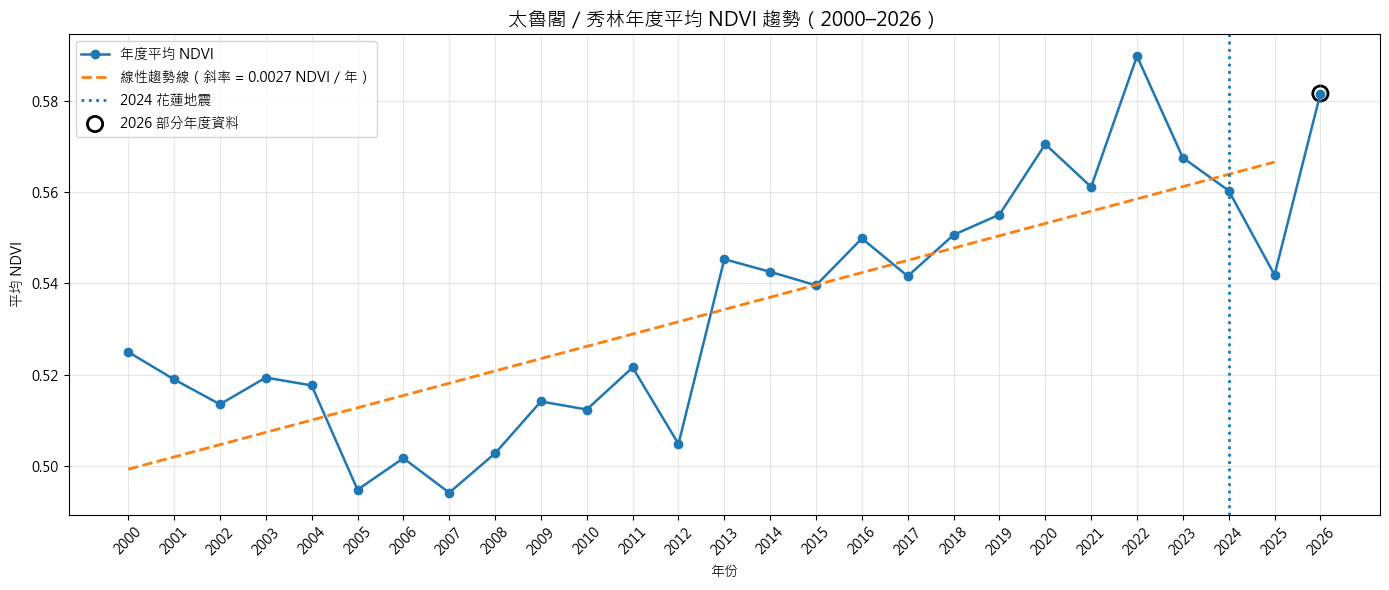

完整年度分析範圍：2000–2025
線性趨勢斜率：0.002692 NDVI／年
26 年累積變化估計：0.069995
R²：0.6419
圖檔已儲存：taroko_annual_ndvi_trend_2000_2026.png


In [15]:
# ============================================================
# Cell 10：繪製太魯閣年度 NDVI 趨勢圖
# ============================================================

# 只使用完整年度資料計算長期趨勢
# 2026 年尚未結束，因此不納入線性回歸
完整年度資料 = annual_ndvi_df[
    annual_ndvi_df["partial_year"] == False
].copy()

# 取得年份與 NDVI
完整年份 = 完整年度資料["year"].to_numpy()
完整_ndvi = 完整年度資料["mean_ndvi"].to_numpy()

# 計算線性趨勢線
斜率, 截距 = np.polyfit(完整年份, 完整_ndvi, 1)
趨勢線 = 斜率 * 完整年份 + 截距

# 計算 R²
預測_ndvi = 趨勢線
殘差平方和 = np.sum((完整_ndvi - 預測_ndvi) ** 2)
總平方和 = np.sum((完整_ndvi - np.mean(完整_ndvi)) ** 2)
r_squared = 1 - 殘差平方和 / 總平方和

# 建立圖表
plt.figure(figsize=(14, 6))

# 繪製所有年度 NDVI
plt.plot(
    annual_ndvi_df["year"],
    annual_ndvi_df["mean_ndvi"],
    marker="o",
    linewidth=1.8,
    label="年度平均 NDVI"
)

# 加入完整年度資料的趨勢線
plt.plot(
    完整年份,
    趨勢線,
    linestyle="--",
    linewidth=2,
    label=f"線性趨勢線（斜率 = {斜率:.4f} NDVI／年）"
)

# 標記 2024 年地震
plt.axvline(
    x=2024,
    linestyle=":",
    linewidth=2,
    label="2024 花蓮地震"
)

# 標記 2026 年為部分年度資料
ndvi_2026 = annual_ndvi_df.loc[
    annual_ndvi_df["year"] == 2026,
    "mean_ndvi"
].iloc[0]

plt.scatter(
    2026,
    ndvi_2026,
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="2026 部分年度資料"
)

# 設定圖表文字
plt.title("太魯閣／秀林年度平均 NDVI 趨勢（2000–2026）", fontsize=14)
plt.xlabel("年份")
plt.ylabel("平均 NDVI")
plt.xticks(range(2000, 2027), rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 儲存圖片
plt.savefig(
    "taroko_annual_ndvi_trend_2000_2026.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 顯示趨勢統計
print(f"完整年度分析範圍：{完整年份.min()}–{完整年份.max()}")
print(f"線性趨勢斜率：{斜率:.6f} NDVI／年")
print(f"26 年累積變化估計：{斜率 * 26:.6f}")
print(f"R²：{r_squared:.4f}")
print("圖檔已儲存：taroko_annual_ndvi_trend_2000_2026.png")

## Cell 11：整理 Task 1 的年度 NDVI 統計摘要

此步驟會找出 NDVI 最低與最高的年份，計算 2024 年地震前後的變化，並整理 Landsat 影像數量。這些結果會用於撰寫 Task 1 的簡短分析。

In [16]:
# ============================================================
# Cell 11：整理 Task 1 的年度 NDVI 統計摘要
# ============================================================

# 排除尚未完成的 2026 年，只分析完整年度資料
完整年度資料 = annual_ndvi_df[
    annual_ndvi_df["partial_year"] == False
].copy()

# 找出 NDVI 最低與最高的五個年份
最低五年 = (
    完整年度資料
    .sort_values("mean_ndvi")
    .head(5)[["year", "mean_ndvi", "image_count"]]
    .reset_index(drop=True)
)

最高五年 = (
    完整年度資料
    .sort_values("mean_ndvi", ascending=False)
    .head(5)[["year", "mean_ndvi", "image_count"]]
    .reset_index(drop=True)
)

# 建立方便查詢年度 NDVI 的函式
def 取得年度_ndvi(年份):
    return float(
        annual_ndvi_df.loc[
            annual_ndvi_df["year"] == 年份,
            "mean_ndvi"
        ].iloc[0]
    )

# 計算重要年度之間的差異
變化_2023至2024 = 取得年度_ndvi(2024) - 取得年度_ndvi(2023)
變化_2024至2025 = 取得年度_ndvi(2025) - 取得年度_ndvi(2024)
變化_2023至2025 = 取得年度_ndvi(2025) - 取得年度_ndvi(2023)

# 檢查 Landsat 7／8 世代轉換附近的差異
變化_2012至2013 = 取得年度_ndvi(2013) - 取得年度_ndvi(2012)

# 計算影像數量統計
影像總數 = int(annual_ndvi_df["image_count"].sum())
完整年度平均影像數量 = 完整年度資料["image_count"].mean()
完整年度最少影像數量 = int(完整年度資料["image_count"].min())
完整年度最多影像數量 = int(完整年度資料["image_count"].max())

print("NDVI 最低的五個完整年度：")
display(最低五年)

print("NDVI 最高的五個完整年度：")
display(最高五年)

print("=" * 60)
print("地震前後 NDVI 變化：")
print(f"2023 → 2024：{變化_2023至2024:+.6f}")
print(f"2024 → 2025：{變化_2024至2025:+.6f}")
print(f"2023 → 2025：{變化_2023至2025:+.6f}")

print("\n跨感測器切換附近的 NDVI 變化：")
print(f"2012 → 2013：{變化_2012至2013:+.6f}")

print("\n影像數量統計：")
print(f"2000–2026 Landsat 影像總數：{影像總數}")
print(f"2000–2025 每年平均影像數量：{完整年度平均影像數量:.2f}")
print(f"2000–2025 單年最少影像數量：{完整年度最少影像數量}")
print(f"2000–2025 單年最多影像數量：{完整年度最多影像數量}")

NDVI 最低的五個完整年度：


,year,mean_ndvi,image_count
0,2007,0.494150,22
1,2005,0.494800,27
2,2006,0.501699,30
3,2008,0.502772,37
4,2012,0.504832,14


NDVI 最高的五個完整年度：


,year,mean_ndvi,image_count
0,2022,0.589789,54
1,2020,0.570498,40
2,2023,0.567536,59
3,2021,0.561140,43
4,2024,0.560317,38


地震前後 NDVI 變化：
2023 → 2024：-0.007219
2024 → 2025：-0.018448
2023 → 2025：-0.025667

跨感測器切換附近的 NDVI 變化：
2012 → 2013：+0.040473

影像數量統計：
2000–2026 Landsat 影像總數：883
2000–2025 每年平均影像數量：33.46
2000–2025 單年最少影像數量：14
2000–2025 單年最多影像數量：59


## Task 1：Landsat 波段調和與長期 NDVI 趨勢分析

本研究整合 Landsat 5、7、8、9 共 883 張影像，建立太魯閣／秀林地區 2000–2026 年的年度 NDVI 時序。以完整年度 2000–2025 年進行線性回歸後，NDVI 趨勢斜率為 0.002692 NDVI／年，顯示研究區整體具有長期綠化趨勢，26 年累積增幅估計約為 0.070。較低的 NDVI 值主要出現在 2005 年與 2007 年，可能與颱風、降雨或其他自然擾動有關。2024 年地震後，平均 NDVI 由 2023 年的 0.567536 下降至 2024 年的 0.560317，並於 2025 年進一步下降至 0.541869，表示部分地區的植被損害仍持續反映在年度合成影像中。另一方面，2012 至 2013 年 NDVI 增加約 0.040473，可能同時受到 Landsat 7 與 Landsat 8 感測器世代切換的影響，因此跨衛星長期趨勢仍需審慎解讀。2026 年資料尚未涵蓋完整年度，因此僅作為補充觀察，不納入趨勢線計算。


## Task2

## Cell 12：建立像素級 NDVI 趨勢分析影像集合

此步驟會為每一張年度 NDVI 合成影像加入年份波段，作為像素級線性回歸的自變數。為避免部分年度資料造成偏差，趨勢分析僅使用 2000–2025 年的 26 個完整年度。

In [18]:
# ============================================================
# Cell 13：建立像素級 NDVI 趨勢分析影像集合
# ============================================================

# 使用 2000–2025 年的完整年度資料進行趨勢分析
趨勢起始年份 = 2000
趨勢結束年份 = 2025

# 篩選完整年度的 NDVI 合成影像
完整年度_ndvi集合 = annual_ndvi_collection.filter(
    ee.Filter.lte("year", 趨勢結束年份)
)


def 加入時間波段(image):
    """
    為年度 NDVI 影像加入年份波段。
    time 為自變數，NDVI 為依變數。
    """

    # 讀取影像對應的年份
    年份 = ee.Number(image.get("year"))

    # 建立年份波段
    時間波段 = ee.Image.constant(年份).float().rename("time")

    # 將 time 波段放在前面，NDVI 波段放在後面
    return (
        時間波段
        .addBands(image.select("NDVI"))
        .copyProperties(image, ["year", "system:time_start"])
    )


# 建立包含 time 與 NDVI 的年度影像集合
annual_trend_collection = 完整年度_ndvi集合.map(加入時間波段)

# 檢查影像集合
趨勢影像數量 = annual_trend_collection.size().getInfo()
趨勢波段名稱 = annual_trend_collection.first().bandNames().getInfo()

print(f"趨勢分析年度範圍：{趨勢起始年份}–{趨勢結束年份}")
print(f"趨勢分析影像數量：{趨勢影像數量}")
print(f"趨勢分析波段名稱：{趨勢波段名稱}")
print("像素級趨勢分析影像集合已建立完成。")

趨勢分析年度範圍：2000–2025
趨勢分析影像數量：26
趨勢分析波段名稱：['time', 'NDVI']
像素級趨勢分析影像集合已建立完成。


## Cell 13：建立像素級 NDVI 線性趨勢圖

此步驟會對每一個像素進行線性回歸，計算 2000–2025 年間的 NDVI 年變化斜率。地圖中的綠色區域代表長期綠化，紅色區域代表長期退化，接近黃色的區域則代表變化較小。

In [19]:
# ============================================================
# Cell 14：建立像素級 NDVI 線性趨勢圖
# ============================================================

# 對每一個像素執行線性回歸
# time 為自變數，NDVI 為依變數
ndvi_trend = (
    annual_trend_collection
    .select(["time", "NDVI"])
    .reduce(ee.Reducer.linearFit())
)

# 取出斜率與截距
# 斜率單位：NDVI／年
ndvi_slope = ndvi_trend.select("scale").rename("NDVI_slope")
ndvi_intercept = ndvi_trend.select("offset").rename("NDVI_intercept")

# 整理為後續匯出使用的影像
ndvi_trend_export = (
    ndvi_slope
    .addBands(ndvi_intercept)
    .clip(aoi)
)

# 設定視覺化參數
# 紅色：退化；黃色：接近穩定；綠色：綠化
斜率視覺化參數 = {
    "min": -0.01,
    "max": 0.01,
    "palette": [
        "8B0000",
        "D73027",
        "FC8D59",
        "FEE08B",
        "FFFFBF",
        "D9EF8B",
        "91CF60",
        "1A9850",
        "006400",
    ],
}

# 建立互動式地圖
趨勢地圖 = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入像素級斜率圖與研究區邊界
趨勢地圖.addLayer(
    ndvi_slope.clip(aoi),
    斜率視覺化參數,
    "NDVI 線性趨勢斜率"
)

趨勢地圖.addLayer(
    aoi,
    {"color": "black"},
    "太魯閣／秀林研究區邊界"
)

# 顯示圖例
趨勢地圖.add_colorbar(
    斜率視覺化參數,
    label="NDVI 趨勢斜率（NDVI／年）",
    layer_name="NDVI 線性趨勢斜率"
)

# 檢查輸出波段名稱
print(f"趨勢影像波段名稱：{ndvi_trend.bandNames().getInfo()}")
print(f"匯出影像波段名稱：{ndvi_trend_export.bandNames().getInfo()}")
print("像素級 NDVI 線性趨勢圖已建立完成。")

趨勢地圖

趨勢影像波段名稱：['scale', 'offset']
匯出影像波段名稱：['NDVI_slope', 'NDVI_intercept']
像素級 NDVI 線性趨勢圖已建立完成。


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Cell 14：統計綠化、退化與穩定區域比例

此步驟會依照 NDVI 每年變化斜率，將像素分為長期綠化、長期退化與相對穩定三類。程式會計算各類別的面積與比例，並顯示分類地圖。

In [20]:
# ============================================================
# Cell 14：統計綠化、退化與穩定區域比例
# ============================================================

# 設定分類門檻
# 斜率單位為 NDVI／年
綠化門檻 = 0.001
退化門檻 = -0.001

# 建立三種趨勢類別的像素遮罩
綠化像素 = ndvi_slope.gt(綠化門檻)
退化像素 = ndvi_slope.lt(退化門檻)
穩定像素 = ndvi_slope.gte(退化門檻).And(
    ndvi_slope.lte(綠化門檻)
)

# 建立分類影像
# -1：長期退化
#  0：相對穩定
#  1：長期綠化
趨勢分類影像 = (
    ee.Image(0)
    .where(退化像素, -1)
    .where(綠化像素, 1)
    .updateMask(ndvi_slope.mask())
    .rename("trend_class")
    .clip(aoi)
)

# 取得每一個像素的實際面積，單位為平方公尺
像素面積 = ee.Image.pixelArea()

# 計算有效像素與各類別的面積
有效面積影像 = (
    像素面積
    .updateMask(ndvi_slope.mask())
    .rename("valid_area")
)

綠化面積影像 = (
    像素面積
    .updateMask(綠化像素)
    .rename("greening_area")
)

退化面積影像 = (
    像素面積
    .updateMask(退化像素)
    .rename("browning_area")
)

穩定面積影像 = (
    像素面積
    .updateMask(穩定像素)
    .rename("stable_area")
)

# 一次計算所有面積，避免送出過多 Earth Engine 統計工作
面積統計 = (
    有效面積影像
    .addBands(綠化面積影像)
    .addBands(退化面積影像)
    .addBands(穩定面積影像)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    )
    .getInfo()
)

# 將平方公尺轉換為公頃
有效面積_公頃 = 面積統計["valid_area"] / 10000
綠化面積_公頃 = 面積統計["greening_area"] / 10000
退化面積_公頃 = 面積統計["browning_area"] / 10000
穩定面積_公頃 = 面積統計["stable_area"] / 10000

# 計算各類別比例
綠化比例 = 綠化面積_公頃 / 有效面積_公頃 * 100
退化比例 = 退化面積_公頃 / 有效面積_公頃 * 100
穩定比例 = 穩定面積_公頃 / 有效面積_公頃 * 100

# 顯示統計結果
print("=" * 60)
print("太魯閣／秀林像素級 NDVI 趨勢統計")
print("=" * 60)
print(f"有效分析面積：{有效面積_公頃:,.2f} 公頃")
print()
print(f"長期綠化面積：{綠化面積_公頃:,.2f} 公頃")
print(f"長期綠化比例：{綠化比例:.2f}%")
print()
print(f"長期退化面積：{退化面積_公頃:,.2f} 公頃")
print(f"長期退化比例：{退化比例:.2f}%")
print()
print(f"相對穩定面積：{穩定面積_公頃:,.2f} 公頃")
print(f"相對穩定比例：{穩定比例:.2f}%")

# 建立趨勢分類地圖
分類視覺化參數 = {
    "min": -1,
    "max": 1,
    "palette": [
        "B2182B",  # 紅色：長期退化
        "FEE08B",  # 黃色：相對穩定
        "1A9850",  # 綠色：長期綠化
    ],
}

趨勢分類地圖 = geemap.Map(center=[24.20, 121.60], zoom=10)

趨勢分類地圖.addLayer(
    趨勢分類影像,
    分類視覺化參數,
    "NDVI 趨勢分類"
)

趨勢分類地圖.addLayer(
    aoi,
    {"color": "black"},
    "太魯閣／秀林研究區邊界"
)

趨勢分類地圖.add_legend(
    title="NDVI 長期趨勢分類",
    legend_dict={
        "長期退化": "B2182B",
        "相對穩定": "FEE08B",
        "長期綠化": "1A9850",
    }
)

趨勢分類地圖

太魯閣／秀林像素級 NDVI 趨勢統計
有效分析面積：177,529.26 公頃

長期綠化面積：150,948.91 公頃
長期綠化比例：85.03%

長期退化面積：8,103.23 公頃
長期退化比例：4.56%

相對穩定面積：18,477.13 公頃
相對穩定比例：10.41%


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Cell 15：將 NDVI 趨勢圖匯出為 GeoTIFF

此步驟會將像素級 NDVI 趨勢圖匯出至 Google Drive。匯出的 GeoTIFF 會包含 NDVI 斜率與截距，並使用作業指定的 EPSG:32651 座標系統。

In [25]:
# ============================================================
# Cell 15：將 NDVI 趨勢圖匯出為 GeoTIFF
# ============================================================

# 建立 Google Drive 匯出工作
趨勢圖匯出工作 = ee.batch.Export.image.toDrive(
    image=ndvi_trend_export,
    description="taroko_ndvi_trend_2000_2025",
    folder="GEE_Exports",
    fileNamePrefix="taroko_ndvi_trend_2000_2025",
    region=aoi,
    scale=30,
    crs="EPSG:32651",
    maxPixels=1e9,
    fileFormat="GeoTIFF"
)

# 啟動匯出工作
趨勢圖匯出工作.start()

# 顯示目前狀態
匯出狀態 = 趨勢圖匯出工作.status()

print("GeoTIFF 匯出工作已啟動。")
print(f"工作名稱：{匯出狀態.get('description')}")
print(f"目前狀態：{匯出狀態.get('state')}")
print("請稍後至 Google Drive 的 GEE_Exports 資料夾確認檔案。")

GeoTIFF 匯出工作已啟動。
工作名稱：taroko_ndvi_trend_2000_2025
目前狀態：READY
請稍後至 Google Drive 的 GEE_Exports 資料夾確認檔案。


## Cell 16：檢查 GeoTIFF 匯出狀態

此步驟會查詢 NDVI 趨勢圖的匯出進度。若顯示 `COMPLETED`，代表 GeoTIFF 已成功儲存至 Google Drive。

In [33]:
# ============================================================
# Cell 16：檢查 GeoTIFF 匯出狀態
# ============================================================

# 查詢先前建立的 Google Drive 匯出工作
匯出狀態 = 趨勢圖匯出工作.status()

print("=" * 60)
print("NDVI 趨勢圖 GeoTIFF 匯出狀態")
print("=" * 60)
print(f"工作名稱：{匯出狀態.get('description')}")
print(f"目前狀態：{匯出狀態.get('state')}")

# 顯示不同狀態下的操作提示
if 匯出狀態.get("state") == "COMPLETED":
    print("匯出已完成。")
    print("請至 Google Drive → GEE_Exports 資料夾確認檔案。")
    print("請截圖保留匯出成果，後續需放入作業中。")

elif 匯出狀態.get("state") in ["READY", "RUNNING"]:
    print("匯出仍在進行中，請稍候一段時間後重新執行此儲存格。")

else:
    print("匯出可能失敗，請查看下方完整狀態資訊。")
    print(匯出狀態)

NDVI 趨勢圖 GeoTIFF 匯出狀態
工作名稱：taroko_ndvi_trend_2000_2025
目前狀態：COMPLETED
匯出已完成。
請至 Google Drive → GEE_Exports 資料夾確認檔案。
請截圖保留匯出成果，後續需放入作業中。


## Task 2：像素級 NDVI 線性趨勢分析

本研究以 2000–2025 年共 26 個完整年度的 Landsat NDVI 中值合成影像，使用 `ee.Reducer.linearFit()` 進行像素級線性趨勢分析。結果顯示，太魯閣／秀林研究區約有 85.03% 的有效分析面積呈現長期綠化趨勢，面積約為 150,948.91 公頃；約有 4.56% 的區域呈現長期退化趨勢，面積約為 8,103.23 公頃；其餘 10.41% 則相對穩定。與 W13 使用 Sentinel-2 進行 6 年分析相比，Landsat 的 26 年資料較能呈現長期植被演替方向，降低單一事件與短期年際波動造成的影響。然而，Sentinel-2 具有 10 公尺解析度，較適合觀察地震後局部崩塌與細部變化；Landsat 則以 30 公尺解析度提供更完整的長期脈絡。因此，短期高解析度分析與長期趨勢分析具有互補性。


## Cell 17：建立桃園台地研究區

此步驟會建立桃園台地的完整分析範圍，以及都市化較明顯的聚焦區域。後續會使用 Landsat 影像與 MNDWI 水體指標，分析埤塘在 2000–2026 年間的變化。

In [34]:
# ============================================================
# Cell 17：建立桃園台地研究區
# ============================================================

# 桃園台地完整研究範圍
# 用於製作 2000–2026 年水體出現頻率圖
TAOYUAN_BBOX = [
    120.94,
    24.83,
    121.35,
    25.08
]

# 都市化聚焦區
# 用於觀察埤塘消失較明顯的區域
TAOYUAN_URBAN_BBOX = [
    121.00,
    24.88,
    121.28,
    25.05
]

# 建立 Earth Engine 幾何範圍
aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)
aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

# 顯示基本資訊
print("桃園台地完整研究區：")
print(TAOYUAN_BBOX)

print("\n桃園都市化聚焦區：")
print(TAOYUAN_URBAN_BBOX)

# 建立互動式地圖
桃園研究區地圖 = geemap.Map(center=[24.96, 121.15], zoom=10)

# 加入完整範圍與聚焦區
桃園研究區地圖.addLayer(
    aoi_taoyuan,
    {"color": "blue"},
    "桃園台地完整研究區"
)

桃園研究區地圖.addLayer(
    aoi_taoyuan_urban,
    {"color": "red"},
    "桃園都市化聚焦區"
)

桃園研究區地圖

桃園台地完整研究區：
[120.94, 24.83, 121.35, 25.08]

桃園都市化聚焦區：
[121.0, 24.88, 121.28, 25.05]


Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 18：載入桃園台地 Landsat 影像

此步驟會載入桃園台地範圍內的 Landsat 5、7、8、9 影像，套用波段調和、反射率校正與雲遮罩，建立後續 MNDWI 水體分析所需的影像集合。

In [35]:
# ============================================================
# Cell 18：載入並合併桃園台地 Landsat 影像
# ============================================================

# 載入 Landsat 5
landsat_5_taoyuan = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2000-01-01", "2013-01-01")
    .map(harmonize_l57)
)

# 載入 Landsat 7
landsat_7_taoyuan = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2000-01-01", ANALYSIS_END)
    .map(harmonize_l57)
)

# 載入 Landsat 8
landsat_8_taoyuan = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2013-01-01", ANALYSIS_END)
    .map(harmonize_l89)
)

# 載入 Landsat 9
landsat_9_taoyuan = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2021-01-01", ANALYSIS_END)
    .map(harmonize_l89)
)

# 合併四代 Landsat 影像，並套用校正與雲遮罩
landsat_taoyuan = (
    landsat_5_taoyuan
    .merge(landsat_7_taoyuan)
    .merge(landsat_8_taoyuan)
    .merge(landsat_9_taoyuan)
    .map(apply_scale_and_mask)
)

# 取得影像數量
count_l5_taoyuan = landsat_5_taoyuan.size().getInfo()
count_l7_taoyuan = landsat_7_taoyuan.size().getInfo()
count_l8_taoyuan = landsat_8_taoyuan.size().getInfo()
count_l9_taoyuan = landsat_9_taoyuan.size().getInfo()
count_all_taoyuan = landsat_taoyuan.size().getInfo()

# 檢查統一後的波段名稱
taoyuan_band_names = landsat_taoyuan.first().bandNames().getInfo()

print(f"分析截止日期：{ANALYSIS_END}")
print("=" * 55)
print(f"桃園 Landsat 5 影像數量：{count_l5_taoyuan}")
print(f"桃園 Landsat 7 影像數量：{count_l7_taoyuan}")
print(f"桃園 Landsat 8 影像數量：{count_l8_taoyuan}")
print(f"桃園 Landsat 9 影像數量：{count_l9_taoyuan}")
print("-" * 55)
print(f"桃園 Landsat 影像總數：{count_all_taoyuan}")
print(f"統一後波段名稱：{taoyuan_band_names}")

分析截止日期：2026-06-01
桃園 Landsat 5 影像數量：511
桃園 Landsat 7 影像數量：1050
桃園 Landsat 8 影像數量：711
桃園 Landsat 9 影像數量：227
-------------------------------------------------------
桃園 Landsat 影像總數：2499
統一後波段名稱：['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


## Cell 19：計算桃園台地 MNDWI

此步驟會使用綠光與短波紅外光波段計算 MNDWI，建立桃園台地的水體指標影像集合。MNDWI 數值較高的區域通常較可能為水體。

In [36]:
# ============================================================
# Cell 19：計算桃園台地 MNDWI
# ============================================================

def compute_mndwi(image):
    """
    計算 MNDWI：
    MNDWI = (Green - SWIR1) / (Green + SWIR1)
    """

    mndwi = image.normalizedDifference(
        ["Green", "SWIR1"]
    ).rename("MNDWI")

    # 保留原始影像拍攝時間
    return mndwi.copyProperties(
        image,
        ["system:time_start"]
    )


# 為桃園台地所有 Landsat 影像計算 MNDWI
mndwi_taoyuan_collection = landsat_taoyuan.map(
    compute_mndwi
)

# 檢查影像數量與波段名稱
mndwi_count = mndwi_taoyuan_collection.size().getInfo()
mndwi_band_names = (
    mndwi_taoyuan_collection
    .first()
    .bandNames()
    .getInfo()
)

print(f"MNDWI 影像數量：{mndwi_count}")
print(f"MNDWI 波段名稱：{mndwi_band_names}")
print("桃園台地 MNDWI 影像集合已建立完成。")

MNDWI 影像數量：2499
MNDWI 波段名稱：['MNDWI']
桃園台地 MNDWI 影像集合已建立完成。


## Cell 20：建立桃園水體出現頻率圖

此步驟會將每一年的 MNDWI 中值影像轉換為水體分類圖，並計算各像素在 2000–2026 年間出現水體的比例。數值越接近 1，代表該位置越常被辨識為水體。

In [37]:
# ============================================================
# Cell 20：建立桃園水體出現頻率圖
# ============================================================

# 設定水體判斷門檻
# MNDWI > 0.1 視為水體
水體門檻 = 0.1


def 建立年度水體影像(年份):
    """
    計算指定年度的 MNDWI 中值合成影像，
    並使用 MNDWI > 0.1 將像素分類為水體或非水體。
    """

    年份 = ee.Number(年份).int()

    # 設定年度起始與結束日期
    起始日期 = ee.Date.fromYMD(年份, 1, 1)
    結束日期 = 起始日期.advance(1, "year")

    # 建立年度 MNDWI 中值合成影像
    年度_mndwi = (
        mndwi_taoyuan_collection
        .filterDate(起始日期, 結束日期)
        .median()
    )

    # 將水體分類為 1，非水體分類為 0
    年度水體 = (
        年度_mndwi
        .gt(水體門檻)
        .rename("water")
    )

    # 儲存年份與時間資訊
    return 年度水體.set({
        "year": 年份,
        "system:time_start": 起始日期.millis(),
    })


# 建立 2000–2026 年的年度水體影像集合
annual_water_collection = ee.ImageCollection(
    年份清單.map(建立年度水體影像)
)

# 計算水體出現頻率
# 例如 0.8 代表 80% 的年度被分類為水體
water_frequency = (
    annual_water_collection
    .mean()
    .rename("water_frequency")
    .clip(aoi_taoyuan)
)

# 檢查集合與波段名稱
年度水體影像數量 = annual_water_collection.size().getInfo()
水體頻率波段名稱 = water_frequency.bandNames().getInfo()

print(f"年度水體影像數量：{年度水體影像數量}")
print(f"水體判斷門檻：MNDWI > {水體門檻}")
print(f"水體頻率波段名稱：{水體頻率波段名稱}")
print("桃園水體出現頻率圖已建立完成。")
print("注意：2026 年僅包含目前已取得的部分年度資料。")

# 設定水體頻率圖顯示方式
水體頻率視覺化參數 = {
    "min": 0,
    "max": 1,
    "palette": [
        "FFFFFF",
        "D6EAF8",
        "85C1E9",
        "3498DB",
        "1F618D",
        "08306B",
    ],
}

# 建立互動式地圖
水體頻率地圖 = geemap.Map(center=[24.96, 121.15], zoom=11)

# 加入水體出現頻率圖
水體頻率地圖.addLayer(
    water_frequency,
    水體頻率視覺化參數,
    "桃園水體出現頻率"
)

# 加入研究區範圍
水體頻率地圖.addLayer(
    aoi_taoyuan,
    {"color": "black"},
    "桃園台地完整研究區"
)

水體頻率地圖.addLayer(
    aoi_taoyuan_urban,
    {"color": "red"},
    "桃園都市化聚焦區"
)

# 加入色條
水體頻率地圖.add_colorbar(
    水體頻率視覺化參數,
    label="水體出現頻率",
    layer_name="桃園水體出現頻率"
)

水體頻率地圖

年度水體影像數量：27
水體判斷門檻：MNDWI > 0.1
水體頻率波段名稱：['water_frequency']
桃園水體出現頻率圖已建立完成。
注意：2026 年僅包含目前已取得的部分年度資料。


Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 21：建立桃園埤塘變遷圖

此步驟會比較 2000–2005 年與 2021–2026 年的水體分布。紅色代表早期為水體、近期已消失的區域；綠色代表近期新增的水體區域。

In [38]:
# ============================================================
# Cell 21：建立桃園埤塘變遷圖
# ============================================================

# 建立早期水體影像：2000–2005 年
early_water = (
    mndwi_taoyuan_collection
    .filterDate("2000-01-01", "2006-01-01")
    .median()
    .gt(水體門檻)
    .rename("early_water")
    .clip(aoi_taoyuan)
)

# 建立近期水體影像：2021 年至目前資料截止日期
# 注意：2026 年僅包含部分年度資料
recent_water = (
    mndwi_taoyuan_collection
    .filterDate("2021-01-01", ANALYSIS_END)
    .median()
    .gt(水體門檻)
    .rename("recent_water")
    .clip(aoi_taoyuan)
)

# 消失水體：早期為水體，近期已非水體
lost_ponds = (
    early_water
    .And(recent_water.Not())
    .rename("lost_ponds")
    .clip(aoi_taoyuan)
)

# 新增水體：早期非水體，近期成為水體
new_water = (
    recent_water
    .And(early_water.Not())
    .rename("new_water")
    .clip(aoi_taoyuan)
)

# 使用 selfMask() 隱藏數值為 0 的像素，只顯示變化區域
lost_ponds_display = lost_ponds.selfMask()
new_water_display = new_water.selfMask()

# 檢查輸出波段名稱
print(f"早期水體波段：{early_water.bandNames().getInfo()}")
print(f"近期水體波段：{recent_water.bandNames().getInfo()}")
print(f"消失水體波段：{lost_ponds.bandNames().getInfo()}")
print(f"新增水體波段：{new_water.bandNames().getInfo()}")
print("桃園埤塘變遷圖層已建立完成。")

# 建立互動式地圖
埤塘變遷地圖 = geemap.Map(center=[24.96, 121.15], zoom=11)

# 加入近期水體作為底圖
埤塘變遷地圖.addLayer(
    recent_water.selfMask(),
    {"palette": ["2E86C1"]},
    "近期水體（2021–2026）"
)

# 加入消失與新增水體圖層
埤塘變遷地圖.addLayer(
    lost_ponds_display,
    {"palette": ["E74C3C"]},
    "消失水體"
)

埤塘變遷地圖.addLayer(
    new_water_display,
    {"palette": ["27AE60"]},
    "新增水體"
)

# 加入研究範圍
埤塘變遷地圖.addLayer(
    aoi_taoyuan,
    {"color": "black"},
    "桃園台地完整研究區"
)

埤塘變遷地圖.addLayer(
    aoi_taoyuan_urban,
    {"color": "yellow"},
    "桃園都市化聚焦區"
)

# 加入圖例
埤塘變遷地圖.add_legend(
    title="桃園水體變遷",
    legend_dict={
        "近期水體": "2E86C1",
        "消失水體": "E74C3C",
        "新增水體": "27AE60",
    }
)

埤塘變遷地圖

早期水體波段：['early_water']
近期水體波段：['recent_water']
消失水體波段：['lost_ponds']
新增水體波段：['new_water']
桃園埤塘變遷圖層已建立完成。


Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 22：估算桃園埤塘變遷面積

此步驟會利用每個像素的實際面積，計算消失水體、新增水體與淨變化量。結果會分別呈現完整桃園台地，以及都市化聚焦區的統計數值。

In [39]:
# ============================================================
# Cell 22：估算桃園埤塘變遷面積
# ============================================================

# 建立每個像素的實際面積影像，單位為平方公尺
像素面積 = ee.Image.pixelArea()

# 將水體變遷像素轉換為面積影像
消失水體面積影像 = (
    lost_ponds
    .multiply(像素面積)
    .rename("lost_area")
)

新增水體面積影像 = (
    new_water
    .multiply(像素面積)
    .rename("new_area")
)

# 合併兩個面積波段，方便一次統計
水體變遷面積影像 = (
    消失水體面積影像
    .addBands(新增水體面積影像)
)


def 計算水體變遷面積(研究區):
    """
    計算指定範圍內的消失水體、新增水體與淨變化面積。
    回傳單位為公頃。
    """

    統計結果 = 水體變遷面積影像.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=研究區,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    ).getInfo()

    # 將平方公尺轉換為公頃
    消失面積_公頃 = 統計結果.get("lost_area", 0) / 10000
    新增面積_公頃 = 統計結果.get("new_area", 0) / 10000

    # 淨變化量：新增面積減去消失面積
    淨變化_公頃 = 新增面積_公頃 - 消失面積_公頃

    return {
        "lost_area_ha": 消失面積_公頃,
        "new_area_ha": 新增面積_公頃,
        "net_change_ha": 淨變化_公頃,
    }


# 計算完整桃園台地的水體變遷面積
桃園完整區統計 = 計算水體變遷面積(aoi_taoyuan)

# 計算都市化聚焦區的水體變遷面積
桃園都市區統計 = 計算水體變遷面積(aoi_taoyuan_urban)

# 顯示完整桃園台地結果
print("=" * 60)
print("桃園台地完整研究區：水體變遷面積")
print("=" * 60)
print(f"消失水體面積：{桃園完整區統計['lost_area_ha']:,.2f} 公頃")
print(f"新增水體面積：{桃園完整區統計['new_area_ha']:,.2f} 公頃")
print(f"水體淨變化量：{桃園完整區統計['net_change_ha']:+,.2f} 公頃")

# 顯示都市化聚焦區結果
print("\n" + "=" * 60)
print("桃園都市化聚焦區：水體變遷面積")
print("=" * 60)
print(f"消失水體面積：{桃園都市區統計['lost_area_ha']:,.2f} 公頃")
print(f"新增水體面積：{桃園都市區統計['new_area_ha']:,.2f} 公頃")
print(f"水體淨變化量：{桃園都市區統計['net_change_ha']:+,.2f} 公頃")

桃園台地完整研究區：水體變遷面積
消失水體面積：580.84 公頃
新增水體面積：162.56 公頃
水體淨變化量：-418.28 公頃

桃園都市化聚焦區：水體變遷面積
消失水體面積：348.13 公頃
新增水體面積：50.71 公頃
水體淨變化量：-297.43 公頃


## Cell 23：載入桃園埤塘驗證資料

此步驟會下載老師提供的 223 口已知埤塘中心點資料，並將 GeoJSON 轉換為 Earth Engine FeatureCollection。後續會利用這些位置檢查 MNDWI 水體偵測結果。

In [40]:
# ============================================================
# Cell 23：載入桃園埤塘驗證資料
# ============================================================

import json
from pathlib import Path
import gdown

# 設定埤塘驗證資料的檔案名稱
埤塘檔案路徑 = Path("taoyuan_ponds_223.geojson")

# 如果尚未下載資料，則從老師提供的 Google Drive 連結下載
if not 埤塘檔案路徑.exists():
    print("正在下載桃園埤塘驗證資料……")

    gdown.download(
        "https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw",
        str(埤塘檔案路徑),
        quiet=False
    )

else:
    print("已找到本機檔案，不需重新下載。")

# 確認檔案是否存在
if not 埤塘檔案路徑.exists():
    raise FileNotFoundError("埤塘 GeoJSON 下載失敗，請確認網路連線。")

# 讀取 GeoJSON
with open(埤塘檔案路徑, "r", encoding="utf-8") as 檔案:
    ponds_geojson = json.load(檔案)

# 檢查 GeoJSON 格式
if ponds_geojson.get("type") != "FeatureCollection":
    raise ValueError("GeoJSON 格式錯誤：應為 FeatureCollection。")

# 將 GeoJSON 中的點位轉換為 Earth Engine Feature
埤塘特徵清單 = []

for 特徵 in ponds_geojson["features"]:

    # 讀取埤塘中心點座標
    座標 = 特徵["geometry"]["coordinates"]

    # 保留原始屬性資料，方便後續查詢未偵測到的埤塘
    屬性 = 特徵.get("properties", {})

    埤塘特徵清單.append(
        ee.Feature(
            ee.Geometry.Point(座標),
            屬性
        )
    )

# 建立 Earth Engine FeatureCollection
ponds_fc = ee.FeatureCollection(埤塘特徵清單)

# 顯示檢查結果
本機埤塘數量 = len(埤塘特徵清單)
gee埤塘數量 = ponds_fc.size().getInfo()

print("=" * 60)
print("桃園埤塘驗證資料載入結果")
print("=" * 60)
print(f"本機 GeoJSON 埤塘數量：{本機埤塘數量}")
print(f"Earth Engine 埤塘數量：{gee埤塘數量}")
print("桃園埤塘驗證資料已載入完成。")

正在下載桃園埤塘驗證資料……


Downloading...
From: https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw
To: c:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework13(week14)\taoyuan_ponds_223.geojson
100%|██████████| 49.7k/49.7k [00:00<00:00, 82.4MB/s]


桃園埤塘驗證資料載入結果
本機 GeoJSON 埤塘數量：223
Earth Engine 埤塘數量：223
桃園埤塘驗證資料已載入完成。


## Cell 24：驗證 MNDWI 埤塘偵測率

此步驟會使用近期水體圖，在 223 口已知埤塘中心點位置取樣。程式會計算成功偵測與未偵測的埤塘數量，並將兩類點位顯示在地圖上。

In [41]:
# ============================================================
# Cell 24：驗證 MNDWI 埤塘偵測率
# ============================================================

# 將沒有有效數值的像素補為 0
# 0：非水體；1：水體
近期水體驗證影像 = recent_water.unmask(0)

# 在 223 口已知埤塘中心點位置取樣
# geometries=True：保留點位座標，方便後續顯示於地圖
埤塘取樣結果 = 近期水體驗證影像.sampleRegions(
    collection=ponds_fc,
    scale=30,
    geometries=True
)

# 分離成功偵測與未偵測的埤塘
已偵測埤塘 = 埤塘取樣結果.filter(
    ee.Filter.eq("recent_water", 1)
)

未偵測埤塘 = 埤塘取樣結果.filter(
    ee.Filter.eq("recent_water", 0)
)

# 計算數量
已知埤塘數量 = ponds_fc.size().getInfo()
已偵測數量 = 已偵測埤塘.size().getInfo()
未偵測數量 = 未偵測埤塘.size().getInfo()

# 計算偵測率
偵測率 = 已偵測數量 / 已知埤塘數量 * 100

# 顯示統計結果
print("=" * 60)
print("桃園埤塘 MNDWI 偵測率驗證")
print("=" * 60)
print(f"已知埤塘數量：{已知埤塘數量}")
print(f"成功偵測數量：{已偵測數量}")
print(f"未偵測數量：{未偵測數量}")
print(f"MNDWI 偵測率：{偵測率:.2f}%")
print(f"水體判斷門檻：MNDWI > {水體門檻}")

# 建立驗證結果地圖
埤塘驗證地圖 = geemap.Map(center=[24.96, 121.15], zoom=11)

# 顯示近期水體
埤塘驗證地圖.addLayer(
    recent_water.selfMask(),
    {"palette": ["2E86C1"]},
    "近期水體"
)

# 顯示成功偵測與未偵測的埤塘位置
埤塘驗證地圖.addLayer(
    已偵測埤塘.style(
        color="00AA00",
        pointSize=5,
        width=1
    ),
    {},
    "成功偵測埤塘"
)

埤塘驗證地圖.addLayer(
    未偵測埤塘.style(
        color="FF0000",
        pointSize=5,
        width=1
    ),
    {},
    "未偵測埤塘"
)

# 加入圖例
埤塘驗證地圖.add_legend(
    title="埤塘驗證結果",
    legend_dict={
        "近期水體": "2E86C1",
        "成功偵測埤塘": "00AA00",
        "未偵測埤塘": "FF0000",
    }
)

埤塘驗證地圖

桃園埤塘 MNDWI 偵測率驗證
已知埤塘數量：223
成功偵測數量：195
未偵測數量：23
MNDWI 偵測率：87.44%
水體判斷門檻：MNDWI > 0.1


Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 24A：修正埤塘取樣範圍並重新計算偵測率

前一個步驟中有少數埤塘點位未進入取樣結果。此步驟會擴展影像的有效範圍，將缺少數值的位置補為非水體，確保 223 口已知埤塘都納入偵測率計算。

In [42]:
# ============================================================
# Cell 24A：修正埤塘取樣範圍並重新計算偵測率
# ============================================================

# 將沒有有效數值的位置補為 0
# sameFootprint=False：擴展有效範圍，避免部分點位被取樣流程略過
近期水體驗證影像_完整範圍 = recent_water.unmask(
    value=0,
    sameFootprint=False
)

# 重新在 223 口已知埤塘中心點位置取樣
埤塘取樣結果_完整範圍 = 近期水體驗證影像_完整範圍.sampleRegions(
    collection=ponds_fc,
    scale=30,
    geometries=True
)

# 分離成功偵測與未偵測埤塘
已偵測埤塘 = 埤塘取樣結果_完整範圍.filter(
    ee.Filter.eq("recent_water", 1)
)

未偵測埤塘 = 埤塘取樣結果_完整範圍.filter(
    ee.Filter.eq("recent_water", 0)
)

# 計算數量
已知埤塘數量 = ponds_fc.size().getInfo()
取樣點位數量 = 埤塘取樣結果_完整範圍.size().getInfo()
已偵測數量 = 已偵測埤塘.size().getInfo()
未偵測數量 = 未偵測埤塘.size().getInfo()

# 計算偵測率
偵測率 = 已偵測數量 / 已知埤塘數量 * 100

# 顯示修正後結果
print("=" * 60)
print("桃園埤塘 MNDWI 偵測率驗證：修正版")
print("=" * 60)
print(f"已知埤塘數量：{已知埤塘數量}")
print(f"完成取樣的點位數量：{取樣點位數量}")
print(f"成功偵測數量：{已偵測數量}")
print(f"未偵測數量：{未偵測數量}")
print(f"MNDWI 偵測率：{偵測率:.2f}%")
print(f"水體判斷門檻：MNDWI > {水體門檻}")

# 檢查數量是否完整
if 取樣點位數量 == 已知埤塘數量:
    print("\n檢查完成：223 口已知埤塘皆已納入驗證。")
else:
    print("\n注意：仍有點位未納入取樣，需進一步檢查座標位置。")

# 更新驗證結果地圖
埤塘驗證地圖 = geemap.Map(center=[24.96, 121.15], zoom=11)

埤塘驗證地圖.addLayer(
    recent_water.selfMask(),
    {"palette": ["2E86C1"]},
    "近期水體"
)

埤塘驗證地圖.addLayer(
    已偵測埤塘.style(
        color="00AA00",
        pointSize=5,
        width=1
    ),
    {},
    "成功偵測埤塘"
)

埤塘驗證地圖.addLayer(
    未偵測埤塘.style(
        color="FF0000",
        pointSize=5,
        width=1
    ),
    {},
    "未偵測埤塘"
)

埤塘驗證地圖.add_legend(
    title="埤塘驗證結果",
    legend_dict={
        "近期水體": "2E86C1",
        "成功偵測埤塘": "00AA00",
        "未偵測埤塘": "FF0000",
    }
)

埤塘驗證地圖

桃園埤塘 MNDWI 偵測率驗證：修正版
已知埤塘數量：223
完成取樣的點位數量：223
成功偵測數量：195
未偵測數量：28
MNDWI 偵測率：87.44%
水體判斷門檻：MNDWI > 0.1

檢查完成：223 口已知埤塘皆已納入驗證。


Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 25：整理桃園埤塘變遷統計摘要

此步驟會彙整桃園台地與都市化聚焦區的水體變化面積，並計算都市化聚焦區占整體水體損失的比例。結果會輸出為表格與 CSV 檔案，方便後續撰寫分析。

In [43]:
# ============================================================
# Cell 25：整理桃園埤塘變遷統計摘要
# ============================================================

# 計算都市化聚焦區占完整桃園台地水體損失的比例
都市區消失水體占比 = (
    桃園都市區統計["lost_area_ha"]
    / 桃園完整區統計["lost_area_ha"]
    * 100
)

# 計算都市化聚焦區占完整桃園台地淨減少量的比例
都市區淨減少占比 = (
    abs(桃園都市區統計["net_change_ha"])
    / abs(桃園完整區統計["net_change_ha"])
    * 100
)

# 建立統計摘要表格
task3_summary_df = pd.DataFrame(
    [
        {
            "研究範圍": "桃園台地完整研究區",
            "消失水體面積_公頃": 桃園完整區統計["lost_area_ha"],
            "新增水體面積_公頃": 桃園完整區統計["new_area_ha"],
            "水體淨變化量_公頃": 桃園完整區統計["net_change_ha"],
        },
        {
            "研究範圍": "桃園都市化聚焦區",
            "消失水體面積_公頃": 桃園都市區統計["lost_area_ha"],
            "新增水體面積_公頃": 桃園都市區統計["new_area_ha"],
            "水體淨變化量_公頃": 桃園都市區統計["net_change_ha"],
        },
    ]
)

# 將數值四捨五入至小數點後兩位
task3_summary_df = task3_summary_df.round(2)

# 顯示統計表格
display(task3_summary_df)

# 顯示重點摘要
print("=" * 60)
print("桃園埤塘變遷分析摘要")
print("=" * 60)
print(f"完整桃園台地消失水體面積：{桃園完整區統計['lost_area_ha']:,.2f} 公頃")
print(f"完整桃園台地新增水體面積：{桃園完整區統計['new_area_ha']:,.2f} 公頃")
print(f"完整桃園台地水體淨變化量：{桃園完整區統計['net_change_ha']:+,.2f} 公頃")
print()
print(f"都市化聚焦區消失水體占比：{都市區消失水體占比:.2f}%")
print(f"都市化聚焦區淨減少量占比：{都市區淨減少占比:.2f}%")
print()
print(f"已知埤塘數量：{已知埤塘數量}")
print(f"成功偵測數量：{已偵測數量}")
print(f"未偵測數量：{未偵測數量}")
print(f"MNDWI 偵測率：{偵測率:.2f}%")

# 儲存 CSV 統計表格
task3_summary_df.to_csv(
    "taoyuan_pond_change_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n統計表格已儲存：taoyuan_pond_change_summary.csv")

,研究範圍,消失水體面積_公頃,新增水體面積_公頃,水體淨變化量_公頃
0,桃園台地完整研究區,580.84,162.56,-418.28
1,桃園都市化聚焦區,348.13,50.71,-297.43


桃園埤塘變遷分析摘要
完整桃園台地消失水體面積：580.84 公頃
完整桃園台地新增水體面積：162.56 公頃
完整桃園台地水體淨變化量：-418.28 公頃

都市化聚焦區消失水體占比：59.94%
都市化聚焦區淨減少量占比：71.11%

已知埤塘數量：223
成功偵測數量：195
未偵測數量：28
MNDWI 偵測率：87.44%

統計表格已儲存：taoyuan_pond_change_summary.csv


## Task 3：桃園埤塘消失與 MNDWI 水體分析

本研究利用 Landsat 5、7、8、9 共 2,499 張影像，透過 MNDWI > 0.1 的門檻建立桃園台地水體分布圖。比較 2000–2005 年與 2021–2026 年的水體範圍後，完整研究區的消失水體面積為 580.84 公頃，新增水體面積為 162.56 公頃，水體淨變化量為 −418.28 公頃，顯示桃園台地的水體面積明顯下降。其中，都市化聚焦區占整體消失水體面積的 59.94%，並占水體淨減少量的 71.11%，表示水體損失主要集中於都市化較明顯的區域。以老師提供的 223 口已知埤塘中心點驗證後，共成功偵測 195 口，MNDWI 門檻法的偵測率為 87.44%。未被偵測的埤塘可能面積較小、受到植被覆蓋、發生季節性乾涸，或因 Landsat 30 公尺解析度產生混合像素。若要提高偵測率，可降低 MNDWI 門檻、針對不同季節分別分析，或使用 Sentinel-2 的 10 公尺影像進一步驗證。


## Task4

## Cell 26：建立植被韌性分析時期

此步驟會依照 2024 年 4 月 3 日地震日期，建立地震前基準期、地震衝擊期與地震後恢復期的 NDVI 中值影像。這三張影像會用於後續計算植被恢復比率。

In [44]:
# ============================================================
# Cell 26：建立植被韌性分析時期
# ============================================================

# 採用課堂 Demo 的精確時間切分方式
# filterDate() 的結束日期不包含當日

# 地震前基準期：2020 年至 2024 年 4 月 3 日地震發生前
基準期開始日期 = "2020-01-01"
基準期結束日期 = "2024-04-03"

# 地震衝擊期：2024 年 4 月 3 日至 2024 年底
衝擊期開始日期 = "2024-04-03"
衝擊期結束日期 = "2025-01-01"

# 地震後恢復期：2025 年 6 月至 2026 年 3 月
# 使用固定期間可降低季節差異造成的影響
恢復期開始日期 = "2025-06-01"
恢復期結束日期 = "2026-04-01"

# 篩選三個時期的 NDVI 影像集合
基準期影像集合 = ndvi_collection.filterDate(
    基準期開始日期,
    基準期結束日期
)

衝擊期影像集合 = ndvi_collection.filterDate(
    衝擊期開始日期,
    衝擊期結束日期
)

恢復期影像集合 = ndvi_collection.filterDate(
    恢復期開始日期,
    恢復期結束日期
)

# 建立三個時期的 NDVI 中值合成影像
baseline_ndvi = (
    基準期影像集合
    .median()
    .rename("baseline_ndvi")
    .clip(aoi)
)

impact_ndvi = (
    衝擊期影像集合
    .median()
    .rename("impact_ndvi")
    .clip(aoi)
)

recovery_ndvi = (
    恢復期影像集合
    .median()
    .rename("recovery_ndvi")
    .clip(aoi)
)

# 顯示各時期的影像數量
基準期影像數量 = 基準期影像集合.size().getInfo()
衝擊期影像數量 = 衝擊期影像集合.size().getInfo()
恢復期影像數量 = 恢復期影像集合.size().getInfo()

print("=" * 60)
print("太魯閣／秀林植被韌性分析時期")
print("=" * 60)
print(
    f"基準期：{基準期開始日期} 至 {基準期結束日期}"
    f"｜影像數量：{基準期影像數量}"
)
print(
    f"衝擊期：{衝擊期開始日期} 至 {衝擊期結束日期}"
    f"｜影像數量：{衝擊期影像數量}"
)
print(
    f"恢復期：{恢復期開始日期} 至 {恢復期結束日期}"
    f"｜影像數量：{恢復期影像數量}"
)

print("\n波段名稱：")
print(f"基準期：{baseline_ndvi.bandNames().getInfo()}")
print(f"衝擊期：{impact_ndvi.bandNames().getInfo()}")
print(f"恢復期：{recovery_ndvi.bandNames().getInfo()}")

print("\n植被韌性分析時期已建立完成。")

太魯閣／秀林植被韌性分析時期
基準期：2020-01-01 至 2024-04-03｜影像數量：207
衝擊期：2024-04-03 至 2025-01-01｜影像數量：27
恢復期：2025-06-01 至 2026-04-01｜影像數量：30

波段名稱：
基準期：['baseline_ndvi']
衝擊期：['impact_ndvi']
恢復期：['recovery_ndvi']

植被韌性分析時期已建立完成。


## Cell 27：計算植被恢復比率

此步驟會計算地震後植被的恢復程度。程式只分析地震後 NDVI 明顯下降的像素，並將受損區域分為持續退化、緩慢恢復、恢復中與超過基準值四種類型。

In [45]:
# ============================================================
# Cell 27：計算植被恢復比率
# ============================================================

# 計算地震造成的 NDVI 損失程度
# 正值代表地震後 NDVI 下降
植被損失程度 = (
    baseline_ndvi
    .subtract(impact_ndvi)
    .rename("damage_magnitude")
)

# 僅保留 NDVI 下降幅度大於 0.05 的像素
# 避免將變化很小或 NDVI 上升的區域誤判為受損區
受損像素遮罩 = 植被損失程度.gt(0.05)

# 計算恢復量
恢復量 = recovery_ndvi.subtract(impact_ndvi)

# 在受損像素範圍內計算植被恢復比率
# Recovery Ratio = (Recovery NDVI - Impact NDVI)
#                  / (Baseline NDVI - Impact NDVI)
recovery_ratio = (
    恢復量
    .divide(植被損失程度.updateMask(受損像素遮罩))
    .rename("recovery_ratio")
    .clamp(-1, 2)
    .clip(aoi)
)

# 建立韌性分類影像
# 0：持續退化，Recovery Ratio < 0
# 1：緩慢恢復，0 ≤ Recovery Ratio < 0.5
# 2：恢復中，0.5 ≤ Recovery Ratio < 1.0
# 3：超過基準值，Recovery Ratio ≥ 1.0
resilience_class = (
    ee.Image(0)
    .where(
        recovery_ratio.gte(0).And(recovery_ratio.lt(0.5)),
        1
    )
    .where(
        recovery_ratio.gte(0.5).And(recovery_ratio.lt(1.0)),
        2
    )
    .where(
        recovery_ratio.gte(1.0),
        3
    )
    .updateMask(recovery_ratio.mask())
    .rename("resilience_class")
    .clip(aoi)
)

# 檢查波段名稱
print(f"植被損失波段：{植被損失程度.bandNames().getInfo()}")
print(f"恢復比率波段：{recovery_ratio.bandNames().getInfo()}")
print(f"韌性分類波段：{resilience_class.bandNames().getInfo()}")
print("植被恢復比率與韌性分類圖層已建立完成。")

# 設定恢復比率視覺化參數
恢復比率視覺化參數 = {
    "min": -1,
    "max": 2,
    "palette": [
        "B2182B",  # 紅色：持續退化
        "F46D43",
        "FEE08B",  # 黃色：恢復較慢
        "66BD63",  # 綠色：接近恢復
        "2166AC",  # 藍色：超過基準值
    ],
}

# 設定韌性分類視覺化參數
韌性分類視覺化參數 = {
    "min": 0,
    "max": 3,
    "palette": [
        "B2182B",  # 紅色：持續退化
        "FEE08B",  # 黃色：緩慢恢復
        "66BD63",  # 綠色：恢復中
        "2166AC",  # 藍色：超過基準值
    ],
}

# 建立互動式地圖
韌性地圖 = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入恢復比率與分類圖層
韌性地圖.addLayer(
    recovery_ratio,
    恢復比率視覺化參數,
    "植被恢復比率"
)

韌性地圖.addLayer(
    resilience_class,
    韌性分類視覺化參數,
    "植被韌性分類"
)

# 加入研究區邊界
韌性地圖.addLayer(
    aoi,
    {"color": "black"},
    "太魯閣／秀林研究區邊界"
)

# 加入圖例
韌性地圖.add_legend(
    title="植被韌性分類",
    legend_dict={
        "持續退化：RR < 0": "B2182B",
        "緩慢恢復：0 ≤ RR < 0.5": "FEE08B",
        "恢復中：0.5 ≤ RR < 1.0": "66BD63",
        "超過基準：RR ≥ 1.0": "2166AC",
    }
)

韌性地圖

植被損失波段：['damage_magnitude']
恢復比率波段：['recovery_ratio']
韌性分類波段：['resilience_class']
植被恢復比率與韌性分類圖層已建立完成。


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Cell 28：統計植被韌性分類比例

此步驟會計算受損區域的總面積，並統計持續退化、緩慢恢復、恢復中與超過基準值四類像素的面積與比例。

In [46]:
# ============================================================
# Cell 28：統計植被韌性分類比例
# ============================================================

# 建立每個像素的實際面積影像，單位為平方公尺
像素面積 = ee.Image.pixelArea()

# 使用恢復比率的遮罩作為有效受損區域
受損區域面積影像 = (
    像素面積
    .updateMask(recovery_ratio.mask())
    .rename("damaged_area")
)

# 建立各韌性分類的面積影像
持續退化面積影像 = (
    像素面積
    .updateMask(resilience_class.eq(0))
    .rename("degrading_area")
)

緩慢恢復面積影像 = (
    像素面積
    .updateMask(resilience_class.eq(1))
    .rename("slow_recovery_area")
)

恢復中面積影像 = (
    像素面積
    .updateMask(resilience_class.eq(2))
    .rename("recovering_area")
)

超過基準面積影像 = (
    像素面積
    .updateMask(resilience_class.eq(3))
    .rename("exceeded_area")
)

# 合併所有面積波段，一次完成統計
韌性面積統計 = (
    受損區域面積影像
    .addBands(持續退化面積影像)
    .addBands(緩慢恢復面積影像)
    .addBands(恢復中面積影像)
    .addBands(超過基準面積影像)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    )
    .getInfo()
)

# 將平方公尺轉換為公頃
受損區域面積_公頃 = 韌性面積統計.get("damaged_area", 0) / 10000
持續退化面積_公頃 = 韌性面積統計.get("degrading_area", 0) / 10000
緩慢恢復面積_公頃 = 韌性面積統計.get("slow_recovery_area", 0) / 10000
恢復中面積_公頃 = 韌性面積統計.get("recovering_area", 0) / 10000
超過基準面積_公頃 = 韌性面積統計.get("exceeded_area", 0) / 10000

# 計算百分比
持續退化比例 = 持續退化面積_公頃 / 受損區域面積_公頃 * 100
緩慢恢復比例 = 緩慢恢復面積_公頃 / 受損區域面積_公頃 * 100
恢復中比例 = 恢復中面積_公頃 / 受損區域面積_公頃 * 100
超過基準比例 = 超過基準面積_公頃 / 受損區域面積_公頃 * 100

# 建立摘要表格
task4_resilience_df = pd.DataFrame(
    [
        {
            "韌性分類": "持續退化",
            "條件": "RR < 0",
            "面積_公頃": 持續退化面積_公頃,
            "比例_百分比": 持續退化比例,
        },
        {
            "韌性分類": "緩慢恢復",
            "條件": "0 ≤ RR < 0.5",
            "面積_公頃": 緩慢恢復面積_公頃,
            "比例_百分比": 緩慢恢復比例,
        },
        {
            "韌性分類": "恢復中",
            "條件": "0.5 ≤ RR < 1.0",
            "面積_公頃": 恢復中面積_公頃,
            "比例_百分比": 恢復中比例,
        },
        {
            "韌性分類": "超過基準值",
            "條件": "RR ≥ 1.0",
            "面積_公頃": 超過基準面積_公頃,
            "比例_百分比": 超過基準比例,
        },
    ]
).round(2)

# 顯示表格與統計結果
display(task4_resilience_df)

print("=" * 60)
print("太魯閣／秀林植被韌性統計")
print("=" * 60)
print(f"受損區域總面積：{受損區域面積_公頃:,.2f} 公頃")
print()
print(f"持續退化：{持續退化面積_公頃:,.2f} 公頃｜{持續退化比例:.2f}%")
print(f"緩慢恢復：{緩慢恢復面積_公頃:,.2f} 公頃｜{緩慢恢復比例:.2f}%")
print(f"恢復中：{恢復中面積_公頃:,.2f} 公頃｜{恢復中比例:.2f}%")
print(f"超過基準值：{超過基準面積_公頃:,.2f} 公頃｜{超過基準比例:.2f}%")

# 儲存統計表格
task4_resilience_df.to_csv(
    "taroko_resilience_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n統計表格已儲存：taroko_resilience_summary.csv")

,韌性分類,條件,面積_公頃,比例_百分比
0,持續退化,RR < 0,3129.03,20.13
1,緩慢恢復,0 ≤ RR < 0.5,5821.06,37.44
2,恢復中,0.5 ≤ RR < 1.0,3693.41,23.76
3,超過基準值,RR ≥ 1.0,2903.94,18.68


太魯閣／秀林植被韌性統計
受損區域總面積：15,547.44 公頃

持續退化：3,129.03 公頃｜20.13%
緩慢恢復：5,821.06 公頃｜37.44%
恢復中：3,693.41 公頃｜23.76%
超過基準值：2,903.94 公頃｜18.68%

統計表格已儲存：taroko_resilience_summary.csv


## Cell 29：將植被韌性圖匯出為 GeoTIFF

此步驟會將植被恢復比率與韌性分類結果匯出至 Google Drive。匯出的 GeoTIFF 會包含恢復比率與四類韌性狀態，並使用 EPSG:32651 座標系統。

In [50]:
# ============================================================
# Cell 29A：修正資料型態並重新匯出植被韌性圖
# ============================================================

# 將兩個波段統一轉換為 Float32
# recovery_ratio 原本為 Float32
# resilience_class 原本為 Byte
植被韌性匯出影像 = (
    recovery_ratio
    .toFloat()
    .addBands(
        resilience_class.toFloat()
    )
    .clip(aoi)
)

# 檢查匯出波段名稱
print(
    f"匯出影像波段名稱："
    f"{植被韌性匯出影像.bandNames().getInfo()}"
)

# 重新建立 Google Drive 匯出工作
植被韌性匯出工作 = ee.batch.Export.image.toDrive(
    image=植被韌性匯出影像,
    description="taroko_vegetation_resilience",
    folder="GEE_Exports",
    fileNamePrefix="taroko_vegetation_resilience",
    region=aoi,
    scale=30,
    crs="EPSG:32651",
    maxPixels=1e9,
    fileFormat="GeoTIFF"
)

# 啟動新的匯出工作
植被韌性匯出工作.start()

# 顯示目前狀態
匯出狀態 = 植被韌性匯出工作.status()

print("=" * 60)
print("修正版植被韌性 GeoTIFF 匯出工作已啟動。")
print(f"工作名稱：{匯出狀態.get('description')}")
print(f"目前狀態：{匯出狀態.get('state')}")
print("請稍後重新執行 Cell 30 檢查匯出狀態。")

匯出影像波段名稱：['recovery_ratio', 'resilience_class']
修正版植被韌性 GeoTIFF 匯出工作已啟動。
工作名稱：taroko_vegetation_resilience
目前狀態：READY
請稍後重新執行 Cell 30 檢查匯出狀態。


## Cell 30：檢查植被韌性 GeoTIFF 匯出狀態

此步驟會查詢植被韌性圖的匯出進度。若顯示 `COMPLETED`，代表 GeoTIFF 已成功儲存至 Google Drive。

In [52]:
# ============================================================
# Cell 30：檢查植被韌性 GeoTIFF 匯出狀態
# ============================================================

# 查詢植被韌性圖匯出工作的目前狀態
匯出狀態 = 植被韌性匯出工作.status()

print("=" * 60)
print("植被韌性 GeoTIFF 匯出狀態")
print("=" * 60)
print(f"工作名稱：{匯出狀態.get('description')}")
print(f"目前狀態：{匯出狀態.get('state')}")

# 顯示不同狀態下的操作提示
if 匯出狀態.get("state") == "COMPLETED":
    print("匯出已完成。")
    print("請至 Google Drive → GEE_Exports 資料夾確認檔案。")
    print("請截圖保留匯出成果，後續可放入作業中。")

elif 匯出狀態.get("state") in ["READY", "RUNNING"]:
    print("匯出仍在進行中，請稍候一段時間後重新執行此儲存格。")

else:
    print("匯出可能失敗，請查看下方完整狀態資訊。")
    print(匯出狀態)

植被韌性 GeoTIFF 匯出狀態
工作名稱：taroko_vegetation_resilience
目前狀態：RUNNING
匯出仍在進行中，請稍候一段時間後重新執行此儲存格。


## Bonus 1

## Cell 31：建立 NDVI、MNDWI 與 NBR 多指標影像集合

此步驟會針對太魯閣／秀林研究區的 Landsat 影像，同時計算 NDVI、MNDWI 與 NBR。三個指標分別用於觀察植被、水文狀態與地表擾動。

In [53]:
# ============================================================
# Cell 31：建立 NDVI、MNDWI 與 NBR 多指標影像集合
# ============================================================

def compute_indices(image):
    """
    同時計算三個遙測指標：

    NDVI  = (NIR - Red) / (NIR + Red)
    MNDWI = (Green - SWIR1) / (Green + SWIR1)
    NBR   = (NIR - SWIR2) / (NIR + SWIR2)
    """

    # 計算植被指標
    ndvi = image.normalizedDifference(
        ["NIR", "Red"]
    ).rename("NDVI")

    # 計算水體與濕度指標
    mndwi = image.normalizedDifference(
        ["Green", "SWIR1"]
    ).rename("MNDWI")

    # 計算地表擾動指標
    nbr = image.normalizedDifference(
        ["NIR", "SWIR2"]
    ).rename("NBR")

    # 合併三個指標，並保留原始影像時間
    return (
        ndvi
        .addBands(mndwi)
        .addBands(nbr)
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )


# 為太魯閣／秀林 Landsat 影像計算三個指標
multi_index_collection = landsat_all.map(
    compute_indices
)

# 檢查影像數量與波段名稱
多指標影像數量 = multi_index_collection.size().getInfo()

多指標波段名稱 = (
    multi_index_collection
    .first()
    .bandNames()
    .getInfo()
)

print(f"多指標影像數量：{多指標影像數量}")
print(f"多指標波段名稱：{多指標波段名稱}")
print("太魯閣／秀林多指標影像集合已建立完成。")

多指標影像數量：883
多指標波段名稱：['NDVI', 'MNDWI', 'NBR']
太魯閣／秀林多指標影像集合已建立完成。


## Cell 32：計算 NDVI、MNDWI 與 NBR 年度平均值

此步驟會逐年計算太魯閣／秀林研究區的 NDVI、MNDWI 與 NBR 平均值，並整理成表格。2026 年尚未結束，因此會另外標記為部分年度資料。

In [54]:
# ============================================================
# Cell 32：計算 NDVI、MNDWI 與 NBR 年度平均值
# ============================================================

import time

# 建立儲存年度統計結果的清單
多指標年度結果 = []

# 逐年依序執行，避免同時啟動過多 Earth Engine 統計工作
for 年份 in range(2000, 2027):

    # 設定年度起始與結束日期
    起始日期 = f"{年份}-01-01"
    結束日期 = f"{年份 + 1}-01-01"

    # 篩選該年度的三指標影像
    年度影像集合 = multi_index_collection.filterDate(
        起始日期,
        結束日期
    )

    # 計算該年度影像數量
    影像數量 = 年度影像集合.size().getInfo()

    # 若該年度沒有影像，三個指標皆記錄為空值
    if 影像數量 == 0:
        平均_ndvi = None
        平均_mndwi = None
        平均_nbr = None

    else:
        # 建立該年度的中值合成影像
        年度合成影像 = 年度影像集合.median()

        # 一次計算三個指標的研究區平均值
        年度統計 = 年度合成影像.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9,
            tileScale=4
        ).getInfo()

        平均_ndvi = 年度統計.get("NDVI")
        平均_mndwi = 年度統計.get("MNDWI")
        平均_nbr = 年度統計.get("NBR")

    # 儲存年度統計結果
    多指標年度結果.append(
        {
            "year": 年份,
            "NDVI": 平均_ndvi,
            "MNDWI": 平均_mndwi,
            "NBR": 平均_nbr,
            "image_count": 影像數量,
            "partial_year": 年份 == 2026,
        }
    )

    # 顯示進度
    print(
        f"{年份}："
        f"影像數量 = {影像數量:>2}，"
        f"NDVI = {平均_ndvi:.6f}，"
        f"MNDWI = {平均_mndwi:.6f}，"
        f"NBR = {平均_nbr:.6f}"
    )

    # 稍微間隔每次請求，降低 Earth Engine 伺服器負擔
    time.sleep(0.5)

# 轉換為 Pandas 表格
multi_index_df = pd.DataFrame(多指標年度結果)

# 顯示完整表格
display(multi_index_df)

# 儲存 CSV
multi_index_df.to_csv(
    "taroko_multi_index_annual_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

# 顯示基本檢查結果
print("=" * 60)
print(f"年度資料筆數：{len(multi_index_df)}")
print(f"缺少 NDVI 數值的年度數量：{multi_index_df['NDVI'].isna().sum()}")
print(f"缺少 MNDWI 數值的年度數量：{multi_index_df['MNDWI'].isna().sum()}")
print(f"缺少 NBR 數值的年度數量：{multi_index_df['NBR'].isna().sum()}")
print(f"影像總數：{multi_index_df['image_count'].sum()}")
print("統計表格已儲存：taroko_multi_index_annual_summary.csv")

2000：影像數量 = 31，NDVI = 0.524979，MNDWI = -0.262122，NBR = 0.494581
2001：影像數量 = 33，NDVI = 0.518961，MNDWI = -0.221952，NBR = 0.516718
2002：影像數量 = 31，NDVI = 0.513521，MNDWI = -0.200691，NBR = 0.518848
2003：影像數量 = 28，NDVI = 0.519373，MNDWI = -0.245120，NBR = 0.503632
2004：影像數量 = 34，NDVI = 0.517646，MNDWI = -0.219592，NBR = 0.525958
2005：影像數量 = 27，NDVI = 0.494800，MNDWI = -0.207925，NBR = 0.504299
2006：影像數量 = 30，NDVI = 0.501699，MNDWI = -0.195077，NBR = 0.508589
2007：影像數量 = 22，NDVI = 0.494150，MNDWI = -0.175128，NBR = 0.527709
2008：影像數量 = 37，NDVI = 0.502772，MNDWI = -0.209913，NBR = 0.505921
2009：影像數量 = 36，NDVI = 0.514135，MNDWI = -0.214411，NBR = 0.518161
2010：影像數量 = 25，NDVI = 0.512370，MNDWI = -0.201018，NBR = 0.523798
2011：影像數量 = 17，NDVI = 0.521584，MNDWI = -0.204007，NBR = 0.509833
2012：影像數量 = 14，NDVI = 0.504832，MNDWI = -0.235538，NBR = 0.484852
2013：影像數量 = 26，NDVI = 0.545305，MNDWI = -0.283929，NBR = 0.456415
2014：影像數量 = 35，NDVI = 0.542537，MNDWI = -0.274288，NBR = 0.306380
2015：影像數量 = 38，NDVI = 0.539578，MNDWI = -

,year,NDVI,MNDWI,NBR,image_count,partial_year
0,2000,0.524979,-0.262122,0.494581,31,False
1,2001,0.518961,-0.221952,0.516718,33,False
2,2002,0.513521,-0.200691,0.518848,31,False
3,2003,0.519373,-0.245120,0.503632,28,False
4,2004,0.517646,-0.219592,0.525958,34,False
5,2005,0.494800,-0.207925,0.504299,27,False
6,2006,0.501699,-0.195077,0.508589,30,False
7,2007,0.494150,-0.175128,0.527709,22,False
8,2008,0.502772,-0.209913,0.505921,37,False
9,2009,0.514135,-0.214411,0.518161,36,False


年度資料筆數：27
缺少 NDVI 數值的年度數量：0
缺少 MNDWI 數值的年度數量：0
缺少 NBR 數值的年度數量：0
影像總數：883
統計表格已儲存：taroko_multi_index_annual_summary.csv


## Cell 33：繪製 NDVI、MNDWI 與 NBR 多指標趨勢儀表板

此步驟會將三個指標繪製為上下排列的年度趨勢圖，並標記 2024 年地震與 2026 年部分年度資料。透過比較不同指標，可以觀察植被、水文與地表擾動是否呈現不同變化模式。

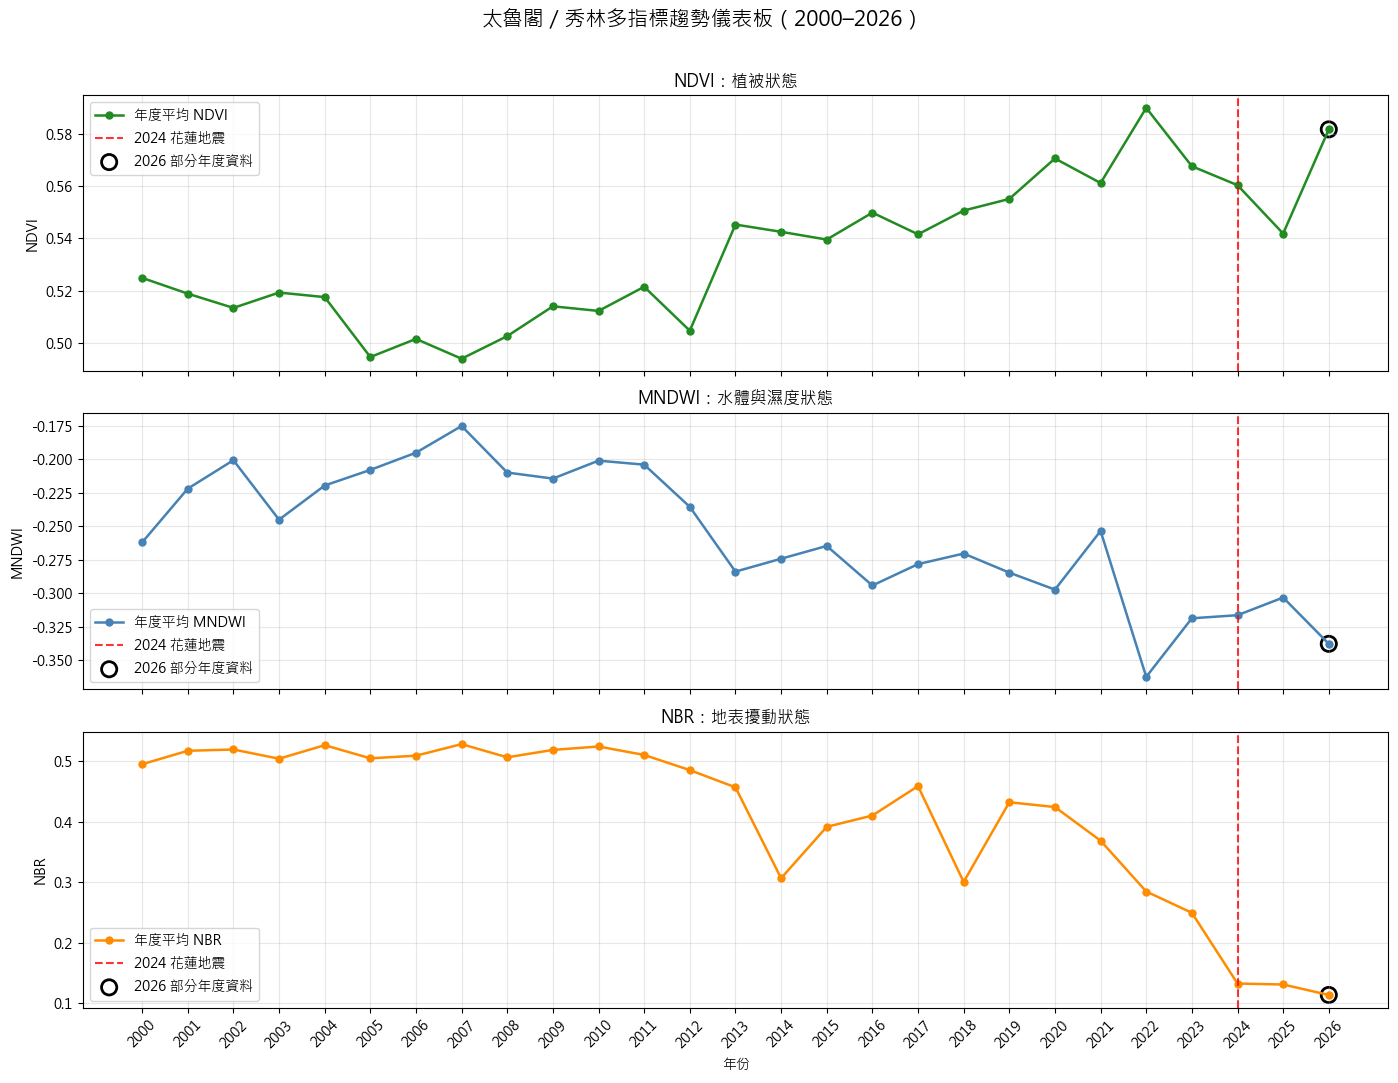

多指標趨勢儀表板已建立完成。
圖檔已儲存：taroko_multi_index_dashboard.png


In [55]:
# ============================================================
# Cell 33：繪製 NDVI、MNDWI 與 NBR 多指標趨勢儀表板
# ============================================================

# 設定三個指標的名稱、顏色與說明
指標設定 = {
    "NDVI": {
        "顏色": "forestgreen",
        "標題": "NDVI：植被狀態",
    },
    "MNDWI": {
        "顏色": "steelblue",
        "標題": "MNDWI：水體與濕度狀態",
    },
    "NBR": {
        "顏色": "darkorange",
        "標題": "NBR：地表擾動狀態",
    },
}

# 建立三個上下排列的子圖
圖表, 子圖清單 = plt.subplots(
    3,
    1,
    figsize=(14, 11),
    sharex=True
)

# 逐一繪製三個指標
for 子圖, (指標名稱, 設定) in zip(
    子圖清單,
    指標設定.items()
):

    # 繪製年度趨勢折線
    子圖.plot(
        multi_index_df["year"],
        multi_index_df[指標名稱],
        color=設定["顏色"],
        marker="o",
        linewidth=1.8,
        markersize=5,
        label=f"年度平均 {指標名稱}"
    )

    # 標記 2024 年花蓮地震
    子圖.axvline(
        x=2024,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="2024 花蓮地震"
    )

    # 取得 2026 年部分年度資料
    指標值_2026 = multi_index_df.loc[
        multi_index_df["year"] == 2026,
        指標名稱
    ].iloc[0]

    # 以空心圓標記 2026 年部分年度資料
    子圖.scatter(
        2026,
        指標值_2026,
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="2026 部分年度資料"
    )

    # 設定子圖格式
    子圖.set_ylabel(指標名稱)
    子圖.set_title(設定["標題"], fontsize=12)
    子圖.grid(alpha=0.3)
    子圖.legend(loc="best")

# 設定共同座標軸
子圖清單[-1].set_xlabel("年份")
子圖清單[-1].set_xticks(range(2000, 2027))
子圖清單[-1].tick_params(
    axis="x",
    rotation=45
)

# 設定整體標題
圖表.suptitle(
    "太魯閣／秀林多指標趨勢儀表板（2000–2026）",
    fontsize=15
)

# 調整圖表間距
plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

# 儲存圖片
plt.savefig(
    "taroko_multi_index_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

# 顯示圖片
plt.show()

print("多指標趨勢儀表板已建立完成。")
print("圖檔已儲存：taroko_multi_index_dashboard.png")

## Bonus 1：NDVI、MNDWI 與 NBR 多指標趨勢比較

三個遙測指標呈現不同的環境變化訊號。NDVI 顯示太魯閣／秀林地區具有長期綠化趨勢，但 2024 年地震後至 2025 年仍可觀察到下降。MNDWI 主要反映水文與濕度狀態，其變化模式與 NDVI 並不完全一致。NBR 在 2024 年與 2025 年出現明顯低值，對地表擾動的反應比 NDVI 更敏感，因此適合搭配 NDVI 判讀災害影響。部分指標在 Landsat 感測器世代切換附近出現跳變，因此跨感測器長期分析仍需審慎解讀。


## Bonus2

## Cell 34：測試下載單一年份的 NDVI 動畫影格

此步驟會先下載 2024 年的年度 NDVI 影像，加入年份與地震事件標記，並顯示測試結果。確認影格正常後，再一次產生 2000–2026 年的完整動畫。

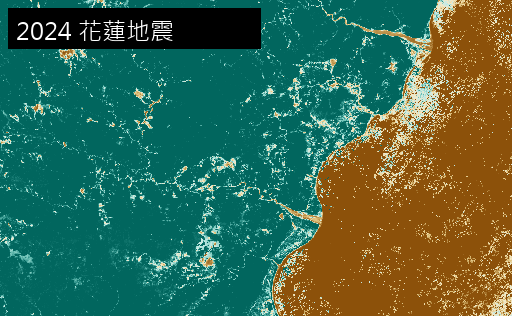

2024 年 NDVI 測試影格已建立完成。
圖片尺寸：(512, 316)
測試影格已儲存：taroko_ndvi_test_frame_2024.png


In [56]:
# ============================================================
# Cell 34：測試下載單一年份的 NDVI 動畫影格
# ============================================================

import io
import os
import requests
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# 設定 NDVI 動畫色階
ndvi_palette = [
    "8C510A",  # 低 NDVI：棕色
    "DFC27D",
    "F6E8C3",
    "C7EAE5",
    "80CDC1",
    "35978F",
    "01665E",  # 高 NDVI：深綠色
]

# 設定測試年份
測試年份 = 2024

# 取得指定年份的年度 NDVI 中值影像
測試影像 = (
    ndvi_collection
    .filterDate(f"{測試年份}-01-01", f"{測試年份 + 1}-01-01")
    .median()
)

# 建立縮圖下載網址
縮圖網址 = 測試影像.getThumbURL(
    {
        "region": aoi,
        "dimensions": 512,
        "min": 0,
        "max": 0.8,
        "palette": ndvi_palette,
        "format": "png",
    }
)

# 下載影像
回應 = requests.get(
    縮圖網址,
    timeout=60
)

回應.raise_for_status()

# 將下載內容轉換為圖片
測試影格 = Image.open(
    io.BytesIO(回應.content)
).convert("RGB")

# 優先使用 Windows 的微軟正黑體
中文字型路徑 = r"C:\Windows\Fonts\msjh.ttc"

if os.path.exists(中文字型路徑):
    標題字型 = ImageFont.truetype(
        中文字型路徑,
        24
    )
else:
    標題字型 = ImageFont.load_default()

# 加入年份與地震標記
繪圖工具 = ImageDraw.Draw(測試影格)

繪圖工具.rectangle(
    [8, 8, 260, 48],
    fill="black"
)

繪圖工具.text(
    (16, 14),
    "2024 花蓮地震",
    fill="white",
    font=標題字型
)

# 儲存測試影格
測試影格.save(
    "taroko_ndvi_test_frame_2024.png"
)

# 顯示結果
display(測試影格)

print("2024 年 NDVI 測試影格已建立完成。")
print(f"圖片尺寸：{測試影格.size}")
print("測試影格已儲存：taroko_ndvi_test_frame_2024.png")

## Cell 35：建立太魯閣年度 NDVI 動畫 GIF

此步驟會逐年下載 2000–2026 年的 NDVI 中值影像，加入年份、重要災害事件與色階圖例，最後組合成動畫 GIF。2026 年尚未結束，因此會標示為部分年度資料。

2000：完成｜年度影像數量 = 31
2001：完成｜年度影像數量 = 33
2002：完成｜年度影像數量 = 31
2003：完成｜年度影像數量 = 28
2004：完成｜年度影像數量 = 34
2005：完成｜年度影像數量 = 27
2006：完成｜年度影像數量 = 30
2007：完成｜年度影像數量 = 22
2008：完成｜年度影像數量 = 37
2009：完成｜年度影像數量 = 36
2010：完成｜年度影像數量 = 25
2011：完成｜年度影像數量 = 17
2012：完成｜年度影像數量 = 14
2013：完成｜年度影像數量 = 26
2014：完成｜年度影像數量 = 35
2015：完成｜年度影像數量 = 38
2016：完成｜年度影像數量 = 33
2017：完成｜年度影像數量 = 34
2018：完成｜年度影像數量 = 37
2019：完成｜年度影像數量 = 35
2020：完成｜年度影像數量 = 40
2021：完成｜年度影像數量 = 43
2022：完成｜年度影像數量 = 54
2023：完成｜年度影像數量 = 59
2024：完成｜年度影像數量 = 38
2025：完成｜年度影像數量 = 33
2026：完成｜年度影像數量 = 13
太魯閣年度 NDVI 動畫已建立完成。
動畫影格數量：27
動畫檔案：taroko_ndvi_2000_2026_timelapse.gif
單張影格資料夾：taroko_ndvi_frames


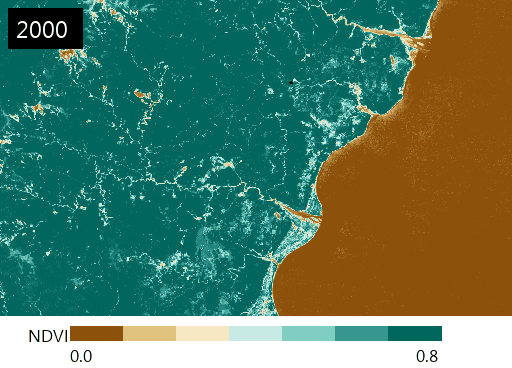

In [57]:
# ============================================================
# Cell 35：建立太魯閣年度 NDVI 動畫 GIF
# ============================================================

import io
import os
import time
import requests
import numpy as np
import imageio.v2 as imageio

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPythonImage

# 建立影格輸出資料夾
影格資料夾 = "taroko_ndvi_frames"
os.makedirs(影格資料夾, exist_ok=True)

# 設定年度範圍
動畫年份清單 = list(range(2000, 2027))

# 設定 NDVI 色階
ndvi_palette = [
    "8C510A",
    "DFC27D",
    "F6E8C3",
    "C7EAE5",
    "80CDC1",
    "35978F",
    "01665E",
]

# 設定重要事件
重要事件 = {
    2009: "莫拉克颱風",
    2015: "蘇迪勒颱風",
    2024: "花蓮地震",
}

# 設定 Windows 中文字型
中文字型路徑 = r"C:\Windows\Fonts\msjh.ttc"

if os.path.exists(中文字型路徑):
    標題字型 = ImageFont.truetype(中文字型路徑, 22)
    圖例字型 = ImageFont.truetype(中文字型路徑, 16)
else:
    標題字型 = ImageFont.load_default()
    圖例字型 = ImageFont.load_default()

# 建立儲存動畫影格的清單
動畫影格清單 = []


def 下載圖片(網址, 最大重試次數=3):
    """
    下載 Earth Engine 縮圖。
    若網路暫時失敗，最多重新嘗試三次。
    """

    for 嘗試次數 in range(1, 最大重試次數 + 1):

        try:
            回應 = requests.get(
                網址,
                timeout=60
            )

            回應.raise_for_status()

            return Image.open(
                io.BytesIO(回應.content)
            ).convert("RGB")

        except Exception as 錯誤:
            print(
                f"下載失敗，第 {嘗試次數} 次重試："
                f"{錯誤}"
            )

            time.sleep(2)

    raise RuntimeError("圖片下載失敗，已達最大重試次數。")


def 加入_ndvi圖例(原始圖片):
    """
    在影像底部加入 NDVI 色階圖例。
    """

    圖例高度 = 52

    # 建立較高的新畫布
    新圖片 = Image.new(
        "RGB",
        (
            原始圖片.width,
            原始圖片.height + 圖例高度
        ),
        "white"
    )

    # 貼上原始影像
    新圖片.paste(
        原始圖片,
        (0, 0)
    )

    繪圖工具 = ImageDraw.Draw(新圖片)

    # 設定色階圖例位置
    起始_x = 70
    結束_x = 新圖片.width - 70
    圖例_y = 原始圖片.height + 10
    圖例寬度 = 結束_x - 起始_x

    # 繪製漸層色條
    for x in range(圖例寬度):

        比例 = x / max(圖例寬度 - 1, 1)

        色階索引 = min(
            int(比例 * len(ndvi_palette)),
            len(ndvi_palette) - 1
        )

        繪圖工具.line(
            [
                (起始_x + x, 圖例_y),
                (起始_x + x, 圖例_y + 14)
            ],
            fill=f"#{ndvi_palette[色階索引]}"
        )

    # 加入圖例文字
    繪圖工具.text(
        (起始_x - 42, 圖例_y - 2),
        "NDVI",
        fill="black",
        font=圖例字型
    )

    繪圖工具.text(
        (起始_x, 圖例_y + 18),
        "0.0",
        fill="black",
        font=圖例字型
    )

    繪圖工具.text(
        (結束_x - 26, 圖例_y + 18),
        "0.8",
        fill="black",
        font=圖例字型
    )

    return 新圖片


# 逐年建立動畫影格
for 年份 in 動畫年份清單:

    # 設定該年度起始與結束日期
    起始日期 = f"{年份}-01-01"
    結束日期 = f"{年份 + 1}-01-01"

    # 取得年度 NDVI 影像集合
    年度影像集合 = ndvi_collection.filterDate(
        起始日期,
        結束日期
    )

    # 計算年度影像數量
    年度影像數量 = 年度影像集合.size().getInfo()

    # 建立年度 NDVI 中值影像
    年度_ndvi影像 = 年度影像集合.median()

    # 建立 Earth Engine 縮圖網址
    縮圖網址 = 年度_ndvi影像.getThumbURL(
        {
            "region": aoi,
            "dimensions": 512,
            "min": 0,
            "max": 0.8,
            "palette": ndvi_palette,
            "format": "png",
        }
    )

    # 下載年度影像
    年度影格 = 下載圖片(縮圖網址)

    # 加入色階圖例
    年度影格 = 加入_ndvi圖例(年度影格)

    # 建立年度標籤
    標籤文字 = f"{年份}"

    if 年份 in 重要事件:
        標籤文字 += f"｜{重要事件[年份]}"

    if 年份 == 2026:
        標籤文字 += "｜部分年度資料"

    if 年度影像數量 < 15:
        標籤文字 += "｜影像較少"

    # 加入黑色文字背景
    繪圖工具 = ImageDraw.Draw(年度影格)

    文字範圍 = 繪圖工具.textbbox(
        (0, 0),
        標籤文字,
        font=標題字型
    )

    文字寬度 = 文字範圍[2] - 文字範圍[0]

    繪圖工具.rectangle(
        [
            8,
            8,
            30 + 文字寬度,
            48
        ],
        fill="black"
    )

    # 加入年份與事件文字
    繪圖工具.text(
        (16, 14),
        標籤文字,
        fill="white",
        font=標題字型
    )

    # 儲存單張影格
    影格檔案路徑 = os.path.join(
        影格資料夾,
        f"taroko_ndvi_{年份}.png"
    )

    年度影格.save(影格檔案路徑)

    # 加入動畫影格清單
    動畫影格清單.append(
        np.array(年度影格)
    )

    print(
        f"{年份}：完成｜"
        f"年度影像數量 = {年度影像數量}"
    )

# 建立 GIF 動畫
動畫檔案名稱 = "taroko_ndvi_2000_2026_timelapse.gif"

imageio.mimsave(
    動畫檔案名稱,
    動畫影格清單,
    duration=0.8,
    loop=0
)

# 顯示完成資訊
print("=" * 60)
print("太魯閣年度 NDVI 動畫已建立完成。")
print(f"動畫影格數量：{len(動畫影格清單)}")
print(f"動畫檔案：{動畫檔案名稱}")
print(f"單張影格資料夾：{影格資料夾}")

# 在 Notebook 中顯示動畫
display(
    IPythonImage(
        filename=動畫檔案名稱
    )
)

## Bonus 2：太魯閣年度 NDVI 動畫觀察

2000–2026 年的 NDVI 動畫呈現太魯閣／秀林地區超過二十年的植被變化。最明顯的現象包括部分年度山區裸露範圍擴大、2024 年花蓮地震後局部植被減少，以及不同年份海岸與河谷附近的變化。整體而言，山區植被仍占主要比例，但局部擾動區域可透過年度動畫更直觀地辨識。


## Bonus3

## Cell 36：載入並處理 Sentinel-2 影像

此步驟會載入 Sentinel-2 Level-2A 地表反射率影像，使用 SCL 場景分類波段去除雲、雲影與雪，並統一整理為後續 NDVI 與地震損害分析需要的波段。

In [58]:
# ============================================================
# Cell 36：載入並處理 Sentinel-2 影像
# ============================================================

def mask_and_scale_sentinel2(image):
    """
    使用 Sentinel-2 SCL 場景分類波段去除無效像素，
    並將原始 DN 值轉換為地表反射率。
    """

    # 讀取場景分類波段
    scl = image.select("SCL")

    # 保留有效像素
    # 0：無資料
    # 1：飽和或損壞像素
    # 3：雲影
    # 8：中等機率雲
    # 9：高機率雲
    # 10：卷雲
    # 11：雪或冰
    valid_mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    # 選取分析需要的波段
    # Sentinel-2 地表反射率需除以 10000
    spectral_bands = (
        image.select(
            ["B2", "B3", "B4", "B8", "B11", "B12"],
            ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
        )
        .multiply(0.0001)
    )

    # 套用遮罩並保留影像時間
    return (
        spectral_bands
        .updateMask(valid_mask)
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )


# 載入 Sentinel-2 Level-2A 地表反射率影像
# 2017 年 4 月起資料較完整
sentinel2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2017-04-01", ANALYSIS_END)
    .filter(
        ee.Filter.lt(
            "CLOUDY_PIXEL_PERCENTAGE",
            80
        )
    )
    .map(mask_and_scale_sentinel2)
)

# 檢查影像數量與波段名稱
sentinel2_count = sentinel2_collection.size().getInfo()

sentinel2_band_names = (
    sentinel2_collection
    .first()
    .bandNames()
    .getInfo()
)

print("=" * 60)
print("Sentinel-2 影像集合檢查")
print("=" * 60)
print(f"分析期間：2017-04-01 至 {ANALYSIS_END}")
print(f"Sentinel-2 影像數量：{sentinel2_count}")
print(f"統一後波段名稱：{sentinel2_band_names}")
print("Sentinel-2 影像集合已建立完成。")

Sentinel-2 影像集合檢查
分析期間：2017-04-01 至 2026-06-01
Sentinel-2 影像數量：736
統一後波段名稱：['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
Sentinel-2 影像集合已建立完成。


## Cell 37：計算 Sentinel-2 年度平均 NDVI

此步驟會為 Sentinel-2 影像計算 NDVI，並逐年整理 2017–2026 年的研究區平均值。2017 年與 2026 年並非完整年度，因此會另外標示。

In [59]:
# ============================================================
# Cell 37：計算 Sentinel-2 年度平均 NDVI
# ============================================================

import time

def compute_sentinel2_ndvi(image):
    """
    計算 Sentinel-2 NDVI：
    NDVI = (NIR - Red) / (NIR + Red)
    """

    ndvi = image.normalizedDifference(
        ["NIR", "Red"]
    ).rename("NDVI")

    # 保留原始影像時間
    return ndvi.copyProperties(
        image,
        ["system:time_start"]
    )


# 建立 Sentinel-2 NDVI 影像集合
sentinel2_ndvi_collection = sentinel2_collection.map(
    compute_sentinel2_ndvi
)

# 檢查 NDVI 波段名稱
print(
    f"Sentinel-2 NDVI 波段名稱："
    f"{sentinel2_ndvi_collection.first().bandNames().getInfo()}"
)

# 建立年度統計結果清單
sentinel2_annual_results = []

# 逐年依序計算，避免 Earth Engine 同時啟動過多統計工作
for 年份 in range(2017, 2027):

    # 2017 年從 4 月開始，其他年份從 1 月開始
    if 年份 == 2017:
        起始日期 = "2017-04-01"
    else:
        起始日期 = f"{年份}-01-01"

    # 2026 年資料截止於 ANALYSIS_END
    if 年份 == 2026:
        結束日期 = ANALYSIS_END
    else:
        結束日期 = f"{年份 + 1}-01-01"

    # 篩選指定年度的 Sentinel-2 NDVI 影像
    年度影像集合 = sentinel2_ndvi_collection.filterDate(
        起始日期,
        結束日期
    )

    # 計算該年度影像數量
    影像數量 = 年度影像集合.size().getInfo()

    # 若該年度沒有影像，NDVI 記錄為空值
    if 影像數量 == 0:
        平均_ndvi = None

    else:
        # 建立年度 NDVI 中值合成影像
        年度_ndvi影像 = 年度影像集合.median()

        # 計算研究區平均 NDVI
        平均_ndvi = 年度_ndvi影像.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=10,
            maxPixels=1e9,
            tileScale=4
        ).get("NDVI").getInfo()

    # 標示是否為部分年度資料
    部分年度 = 年份 in [2017, 2026]

    # 儲存年度結果
    sentinel2_annual_results.append(
        {
            "year": 年份,
            "sentinel2_ndvi": 平均_ndvi,
            "sentinel2_image_count": 影像數量,
            "partial_year": 部分年度,
        }
    )

    # 顯示目前進度
    print(
        f"{年份}："
        f"影像數量 = {影像數量:>3}，"
        f"平均 NDVI = {平均_ndvi}"
    )

    # 稍微間隔每次請求
    time.sleep(0.5)

# 轉換為 Pandas 表格
sentinel2_annual_df = pd.DataFrame(
    sentinel2_annual_results
)

# 顯示完整表格
display(sentinel2_annual_df)

# 儲存 CSV
sentinel2_annual_df.to_csv(
    "taroko_sentinel2_annual_ndvi.csv",
    index=False,
    encoding="utf-8-sig"
)

# 顯示檢查結果
print("=" * 60)
print(f"年度資料筆數：{len(sentinel2_annual_df)}")
print(
    f"缺少 NDVI 數值的年度數量："
    f"{sentinel2_annual_df['sentinel2_ndvi'].isna().sum()}"
)
print(
    f"Sentinel-2 影像總數："
    f"{sentinel2_annual_df['sentinel2_image_count'].sum()}"
)
print("統計表格已儲存：taroko_sentinel2_annual_ndvi.csv")

Sentinel-2 NDVI 波段名稱：['NDVI']
2017：影像數量 =   0，平均 NDVI = None
2018：影像數量 =   5，平均 NDVI = 0.4974012806757215
2019：影像數量 = 101，平均 NDVI = 0.500950937862204
2020：影像數量 = 110，平均 NDVI = 0.5061742522356306
2021：影像數量 = 114，平均 NDVI = 0.492608821079019
2022：影像數量 =  83，平均 NDVI = 0.5247201236090752
2023：影像數量 =  83，平均 NDVI = 0.5122463986047877
2024：影像數量 =  98，平均 NDVI = 0.49929748451026784
2025：影像數量 =  99，平均 NDVI = 0.5088400594456872
2026：影像數量 =  43，平均 NDVI = 0.4925209640481065


,year,sentinel2_ndvi,sentinel2_image_count,partial_year
0,2017,NaN,0,True
1,2018,0.497401,5,False
2,2019,0.500951,101,False
3,2020,0.506174,110,False
4,2021,0.492609,114,False
5,2022,0.524720,83,False
6,2023,0.512246,83,False
7,2024,0.499297,98,False
8,2025,0.508840,99,False
9,2026,0.492521,43,True


年度資料筆數：10
缺少 NDVI 數值的年度數量：1
Sentinel-2 影像總數：736
統計表格已儲存：taroko_sentinel2_annual_ndvi.csv


## Cell 38：整理 Landsat 與 Sentinel-2 年度 NDVI 比較資料

此步驟會合併 Landsat 與 Sentinel-2 的年度平均 NDVI，整理跨感測器比較表格。表格保留 2017–2026 年的資料，但後續回歸分析僅使用資料較完整的 2019–2025 年。

In [60]:
# ============================================================
# Cell 38：整理 Landsat 與 Sentinel-2 年度 NDVI 比較資料
# ============================================================

# 取出 Landsat 年度 NDVI 欄位
landsat_overlap_df = (
    annual_ndvi_df[
        ["year", "mean_ndvi", "image_count", "partial_year"]
    ]
    .rename(
        columns={
            "mean_ndvi": "landsat_ndvi",
            "image_count": "landsat_image_count",
            "partial_year": "landsat_partial_year",
        }
    )
)

# 取出 Sentinel-2 年度 NDVI 欄位
sentinel2_overlap_df = (
    sentinel2_annual_df[
        [
            "year",
            "sentinel2_ndvi",
            "sentinel2_image_count",
            "partial_year",
        ]
    ]
    .rename(
        columns={
            "partial_year": "sentinel2_partial_year",
        }
    )
)

# 合併 2017–2026 年的跨感測器資料
cross_sensor_df = (
    landsat_overlap_df
    .merge(
        sentinel2_overlap_df,
        on="year",
        how="inner"
    )
    .sort_values("year")
    .reset_index(drop=True)
)

# 設定是否納入後續回歸分析
# 使用 2019–2025 年的完整且較充足資料
cross_sensor_df["used_for_regression"] = (
    cross_sensor_df["year"].between(2019, 2025)
    & cross_sensor_df["landsat_ndvi"].notna()
    & cross_sensor_df["sentinel2_ndvi"].notna()
)

# 加入資料備註
def 建立資料備註(row):

    if row["year"] == 2017:
        return "Sentinel-2 無可用影像"

    if row["year"] == 2018:
        return "Sentinel-2 影像較少，不納入回歸"

    if row["year"] == 2026:
        return "部分年度資料，不納入回歸"

    return "納入回歸分析"


cross_sensor_df["note"] = cross_sensor_df.apply(
    建立資料備註,
    axis=1
)

# 建立實際用於回歸分析的表格
cross_sensor_regression_df = (
    cross_sensor_df[
        cross_sensor_df["used_for_regression"]
    ]
    .copy()
    .reset_index(drop=True)
)

# 顯示完整比較表格
display(cross_sensor_df)

# 顯示回歸分析使用的資料
print("=" * 70)
print("跨感測器回歸分析使用的年度資料")
print("=" * 70)

display(
    cross_sensor_regression_df[
        [
            "year",
            "landsat_ndvi",
            "sentinel2_ndvi",
            "landsat_image_count",
            "sentinel2_image_count",
        ]
    ]
)

# 儲存 CSV
cross_sensor_df.to_csv(
    "taroko_landsat_sentinel2_ndvi_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

# 顯示基本檢查結果
print("=" * 70)
print(f"跨感測器比較年度範圍：{cross_sensor_df['year'].min()}–{cross_sensor_df['year'].max()}")
print(f"比較表格年度數量：{len(cross_sensor_df)}")
print(f"納入回歸分析的年度數量：{len(cross_sensor_regression_df)}")
print(
    "納入回歸分析的年份："
    + ", ".join(
        cross_sensor_regression_df["year"]
        .astype(str)
        .tolist()
    )
)
print("比較表格已儲存：taroko_landsat_sentinel2_ndvi_comparison.csv")

,year,landsat_ndvi,landsat_image_count,landsat_partial_year,sentinel2_ndvi,sentinel2_image_count,sentinel2_partial_year,used_for_regression,note
0,2017,0.541584,34,False,NaN,0,True,False,Sentinel-2 無可用影像
1,2018,0.550636,37,False,0.497401,5,False,False,Sentinel-2 影像較少，不納入回歸
2,2019,0.555073,35,False,0.500951,101,False,True,納入回歸分析
3,2020,0.570498,40,False,0.506174,110,False,True,納入回歸分析
4,2021,0.561140,43,False,0.492609,114,False,True,納入回歸分析
5,2022,0.589789,54,False,0.524720,83,False,True,納入回歸分析
6,2023,0.567536,59,False,0.512246,83,False,True,納入回歸分析
7,2024,0.560317,38,False,0.499297,98,False,True,納入回歸分析
8,2025,0.541869,33,False,0.508840,99,False,True,納入回歸分析
9,2026,0.581591,13,True,0.492521,43,True,False,部分年度資料，不納入回歸


跨感測器回歸分析使用的年度資料


,year,landsat_ndvi,sentinel2_ndvi,landsat_image_count,sentinel2_image_count
0,2019,0.555073,0.500951,35,101
1,2020,0.570498,0.506174,40,110
2,2021,0.561140,0.492609,43,114
3,2022,0.589789,0.524720,54,83
4,2023,0.567536,0.512246,59,83
5,2024,0.560317,0.499297,38,98
6,2025,0.541869,0.508840,33,99


跨感測器比較年度範圍：2017–2026
比較表格年度數量：10
納入回歸分析的年度數量：7
納入回歸分析的年份：2019, 2020, 2021, 2022, 2023, 2024, 2025
比較表格已儲存：taroko_landsat_sentinel2_ndvi_comparison.csv


## Cell 39：繪製 Landsat 與 Sentinel-2 年度 NDVI 散點圖

此步驟會比較 Landsat 與 Sentinel-2 的年度平均 NDVI，並建立線性回歸模型。散點圖會顯示 R²、回歸線與 1:1 參考線，用來判斷兩種感測器的結果是否一致。

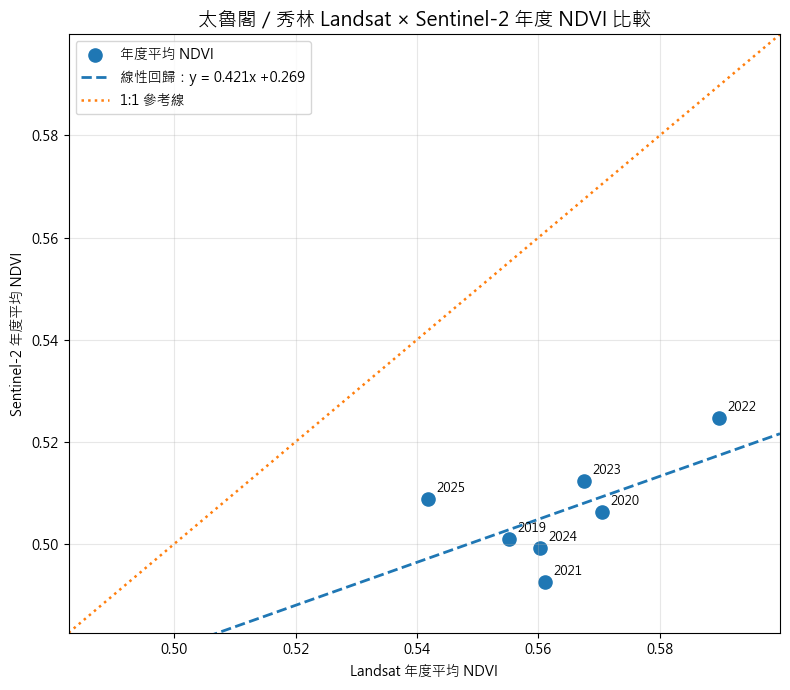

Landsat × Sentinel-2 年度 NDVI 回歸分析
回歸分析年度：2019, 2020, 2021, 2022, 2023, 2024, 2025
資料點數量：7
回歸斜率：0.421131
回歸截距：0.268995
R²：0.3597
Sentinel-2 − Landsat 平均 NDVI 差異：-0.057340
圖檔已儲存：taroko_landsat_sentinel2_ndvi_scatter.png


In [61]:
# ============================================================
# Cell 39：繪製 Landsat 與 Sentinel-2 年度 NDVI 散點圖
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 取出回歸分析需要的資料
landsat_x = (
    cross_sensor_regression_df["landsat_ndvi"]
    .to_numpy()
    .reshape(-1, 1)
)

sentinel2_y = (
    cross_sensor_regression_df["sentinel2_ndvi"]
    .to_numpy()
)

年份陣列 = (
    cross_sensor_regression_df["year"]
    .to_numpy()
)

# 建立線性回歸模型
跨感測器模型 = LinearRegression()

跨感測器模型.fit(
    landsat_x,
    sentinel2_y
)

# 計算預測值與 R²
預測_sentinel2_ndvi = 跨感測器模型.predict(
    landsat_x
)

跨感測器_r2 = r2_score(
    sentinel2_y,
    預測_sentinel2_ndvi
)

# 取得迴歸係數
回歸斜率 = 跨感測器模型.coef_[0]
回歸截距 = 跨感測器模型.intercept_

# 計算 Sentinel-2 與 Landsat 的平均差異
平均_ndvi差異 = (
    cross_sensor_regression_df["sentinel2_ndvi"]
    - cross_sensor_regression_df["landsat_ndvi"]
).mean()

# 建立繪圖範圍
最小值 = min(
    cross_sensor_regression_df["landsat_ndvi"].min(),
    cross_sensor_regression_df["sentinel2_ndvi"].min()
) - 0.01

最大值 = max(
    cross_sensor_regression_df["landsat_ndvi"].max(),
    cross_sensor_regression_df["sentinel2_ndvi"].max()
) + 0.01

回歸線_x = np.linspace(
    最小值,
    最大值,
    100
)

回歸線_y = (
    回歸斜率 * 回歸線_x
    + 回歸截距
)

# 建立散點圖
plt.figure(figsize=(8, 7))

# 繪製年度散點
plt.scatter(
    cross_sensor_regression_df["landsat_ndvi"],
    cross_sensor_regression_df["sentinel2_ndvi"],
    s=90,
    label="年度平均 NDVI"
)

# 加入年度標籤
for _, 資料列 in cross_sensor_regression_df.iterrows():

    plt.annotate(
        str(int(資料列["year"])),
        (
            資料列["landsat_ndvi"],
            資料列["sentinel2_ndvi"]
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

# 繪製線性回歸線
plt.plot(
    回歸線_x,
    回歸線_y,
    linestyle="--",
    linewidth=2,
    label=(
        f"線性回歸：y = "
        f"{回歸斜率:.3f}x "
        f"{回歸截距:+.3f}"
    )
)

# 繪製 1:1 參考線
plt.plot(
    [最小值, 最大值],
    [最小值, 最大值],
    linestyle=":",
    linewidth=1.8,
    label="1:1 參考線"
)

# 設定圖表格式
plt.title(
    "太魯閣／秀林 Landsat × Sentinel-2 年度 NDVI 比較",
    fontsize=14
)

plt.xlabel("Landsat 年度平均 NDVI")
plt.ylabel("Sentinel-2 年度平均 NDVI")

plt.xlim(最小值, 最大值)
plt.ylim(最小值, 最大值)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 儲存圖片
plt.savefig(
    "taroko_landsat_sentinel2_ndvi_scatter.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 顯示統計摘要
print("=" * 65)
print("Landsat × Sentinel-2 年度 NDVI 回歸分析")
print("=" * 65)
print(
    "回歸分析年度："
    + ", ".join(
        cross_sensor_regression_df["year"]
        .astype(str)
        .tolist()
    )
)
print(f"資料點數量：{len(cross_sensor_regression_df)}")
print(f"回歸斜率：{回歸斜率:.6f}")
print(f"回歸截距：{回歸截距:.6f}")
print(f"R²：{跨感測器_r2:.4f}")
print(
    f"Sentinel-2 − Landsat 平均 NDVI 差異："
    f"{平均_ndvi差異:+.6f}"
)
print(
    "圖檔已儲存："
    "taroko_landsat_sentinel2_ndvi_scatter.png"
)

## Cell 40：建立 Landsat 與 Sentinel-2 地震 ΔNDVI 圖層

此步驟會分別使用 Landsat 與 Sentinel-2 建立地震前後的 NDVI 中值影像，並計算 ΔNDVI。負值代表地震後植被減少，正值則代表植被增加。

In [62]:
# ============================================================
# Cell 40：建立 Landsat 與 Sentinel-2 地震 ΔNDVI 圖層
# ============================================================

# 設定地震前後比較期間
# 使用相同長度的年度時間窗，降低季節差異造成的影響
地震前開始日期 = "2023-04-03"
地震前結束日期 = "2024-04-03"

地震後開始日期 = "2024-04-03"
地震後結束日期 = "2025-04-03"

# ------------------------------------------------------------
# Landsat：建立地震前後 NDVI 合成影像
# ------------------------------------------------------------

landsat_pre_collection = ndvi_collection.filterDate(
    地震前開始日期,
    地震前結束日期
)

landsat_post_collection = ndvi_collection.filterDate(
    地震後開始日期,
    地震後結束日期
)

landsat_pre_ndvi = (
    landsat_pre_collection
    .median()
    .rename("landsat_pre_ndvi")
    .clip(aoi)
)

landsat_post_ndvi = (
    landsat_post_collection
    .median()
    .rename("landsat_post_ndvi")
    .clip(aoi)
)

# ΔNDVI = 地震後 NDVI − 地震前 NDVI
landsat_delta_ndvi = (
    landsat_post_ndvi
    .subtract(landsat_pre_ndvi)
    .rename("landsat_delta_ndvi")
    .clip(aoi)
)

# ------------------------------------------------------------
# Sentinel-2：建立地震前後 NDVI 合成影像
# ------------------------------------------------------------

sentinel2_pre_collection = sentinel2_ndvi_collection.filterDate(
    地震前開始日期,
    地震前結束日期
)

sentinel2_post_collection = sentinel2_ndvi_collection.filterDate(
    地震後開始日期,
    地震後結束日期
)

sentinel2_pre_ndvi = (
    sentinel2_pre_collection
    .median()
    .rename("sentinel2_pre_ndvi")
    .clip(aoi)
)

sentinel2_post_ndvi = (
    sentinel2_post_collection
    .median()
    .rename("sentinel2_post_ndvi")
    .clip(aoi)
)

# ΔNDVI = 地震後 NDVI − 地震前 NDVI
sentinel2_delta_ndvi = (
    sentinel2_post_ndvi
    .subtract(sentinel2_pre_ndvi)
    .rename("sentinel2_delta_ndvi")
    .clip(aoi)
)

# ------------------------------------------------------------
# 檢查影像數量與輸出波段
# ------------------------------------------------------------

print("=" * 70)
print("地震前後 ΔNDVI 分析期間")
print("=" * 70)
print(f"地震前：{地震前開始日期} 至 {地震前結束日期}")
print(f"地震後：{地震後開始日期} 至 {地震後結束日期}")

print("\nLandsat 影像數量：")
print(f"地震前：{landsat_pre_collection.size().getInfo()}")
print(f"地震後：{landsat_post_collection.size().getInfo()}")

print("\nSentinel-2 影像數量：")
print(f"地震前：{sentinel2_pre_collection.size().getInfo()}")
print(f"地震後：{sentinel2_post_collection.size().getInfo()}")

print("\nΔNDVI 波段名稱：")
print(f"Landsat：{landsat_delta_ndvi.bandNames().getInfo()}")
print(f"Sentinel-2：{sentinel2_delta_ndvi.bandNames().getInfo()}")

# ------------------------------------------------------------
# 建立 ΔNDVI 比較地圖
# ------------------------------------------------------------

delta_ndvi視覺化參數 = {
    "min": -0.3,
    "max": 0.3,
    "palette": [
        "B2182B",  # 紅色：植被明顯減少
        "EF8A62",
        "FDDBC7",
        "F7F7F7",  # 白色：變化較小
        "D9F0D3",
        "7FBF7B",
        "1B7837",  # 綠色：植被增加
    ],
}

跨感測器_delta地圖 = geemap.Map(
    center=[24.20, 121.60],
    zoom=10
)

# 加入 Landsat ΔNDVI
跨感測器_delta地圖.addLayer(
    landsat_delta_ndvi,
    delta_ndvi視覺化參數,
    "Landsat ΔNDVI（30 公尺）"
)

# 加入 Sentinel-2 ΔNDVI
跨感測器_delta地圖.addLayer(
    sentinel2_delta_ndvi,
    delta_ndvi視覺化參數,
    "Sentinel-2 ΔNDVI（10 公尺）"
)

# 加入研究區邊界
跨感測器_delta地圖.addLayer(
    aoi,
    {"color": "black"},
    "太魯閣／秀林研究區邊界"
)

# 加入色條
跨感測器_delta地圖.add_colorbar(
    delta_ndvi視覺化參數,
    label="ΔNDVI：地震後 − 地震前",
    layer_name="Landsat ΔNDVI（30 公尺）"
)

跨感測器_delta地圖

地震前後 ΔNDVI 分析期間
地震前：2023-04-03 至 2024-04-03
地震後：2024-04-03 至 2025-04-03

Landsat 影像數量：
地震前：52
地震後：33

Sentinel-2 影像數量：
地震前：85
地震後：88

ΔNDVI 波段名稱：
Landsat：['landsat_delta_ndvi']
Sentinel-2：['sentinel2_delta_ndvi']


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Cell 41：比較 Landsat 與 Sentinel-2 的地震受損面積

此步驟會使用 ΔNDVI < −0.15 作為植被受損門檻，分別計算 Landsat 與 Sentinel-2 偵測到的受損面積。結果可用來比較 30 公尺與 10 公尺解析度對地震損害估算的影響。

In [63]:
# ============================================================
# Cell 41：比較 Landsat 與 Sentinel-2 的地震受損面積
# ============================================================

# 設定植被受損判斷門檻
# ΔNDVI = 地震後 NDVI − 地震前 NDVI
# 小於 -0.15 代表植被明顯減少
地震受損門檻 = -0.15

# ------------------------------------------------------------
# 建立 Landsat 與 Sentinel-2 受損區域遮罩
# ------------------------------------------------------------

landsat_damage_mask = (
    landsat_delta_ndvi
    .lt(地震受損門檻)
    .rename("landsat_damage")
    .clip(aoi)
)

sentinel2_damage_mask = (
    sentinel2_delta_ndvi
    .lt(地震受損門檻)
    .rename("sentinel2_damage")
    .clip(aoi)
)

# ------------------------------------------------------------
# 計算受損面積
# ------------------------------------------------------------

像素面積 = ee.Image.pixelArea()

# Landsat 受損面積影像
landsat_damage_area_image = (
    landsat_damage_mask
    .selfMask()
    .multiply(像素面積)
    .rename("landsat_damage_area")
)

# Sentinel-2 受損面積影像
sentinel2_damage_area_image = (
    sentinel2_damage_mask
    .selfMask()
    .multiply(像素面積)
    .rename("sentinel2_damage_area")
)

# 計算 Landsat 受損面積
landsat_damage_area_m2 = (
    landsat_damage_area_image
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    )
    .get("landsat_damage_area")
    .getInfo()
)

# 計算 Sentinel-2 受損面積
sentinel2_damage_area_m2 = (
    sentinel2_damage_area_image
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9,
        tileScale=4
    )
    .get("sentinel2_damage_area")
    .getInfo()
)

# 將平方公尺轉換為公頃
landsat_damage_area_ha = landsat_damage_area_m2 / 10000
sentinel2_damage_area_ha = sentinel2_damage_area_m2 / 10000

# 計算兩種感測器的面積差異
damage_area_difference_ha = (
    sentinel2_damage_area_ha
    - landsat_damage_area_ha
)

damage_area_difference_percent = (
    damage_area_difference_ha
    / landsat_damage_area_ha
    * 100
)

# ------------------------------------------------------------
# 建立面積比較表格
# ------------------------------------------------------------

damage_area_comparison_df = pd.DataFrame(
    [
        {
            "感測器": "Landsat",
            "空間解析度": "30 公尺",
            "受損門檻": "ΔNDVI < -0.15",
            "受損面積_公頃": landsat_damage_area_ha,
        },
        {
            "感測器": "Sentinel-2",
            "空間解析度": "10 公尺",
            "受損門檻": "ΔNDVI < -0.15",
            "受損面積_公頃": sentinel2_damage_area_ha,
        },
    ]
).round(2)

display(damage_area_comparison_df)

# 儲存 CSV
damage_area_comparison_df.to_csv(
    "taroko_cross_sensor_damage_area_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

# 顯示統計摘要
print("=" * 70)
print("Landsat × Sentinel-2 地震受損面積比較")
print("=" * 70)
print(f"受損門檻：ΔNDVI < {地震受損門檻}")
print(f"Landsat 受損面積：{landsat_damage_area_ha:,.2f} 公頃")
print(f"Sentinel-2 受損面積：{sentinel2_damage_area_ha:,.2f} 公頃")
print(f"Sentinel-2 − Landsat 面積差異：{damage_area_difference_ha:+,.2f} 公頃")
print(f"相對於 Landsat 的差異比例：{damage_area_difference_percent:+.2f}%")
print(
    "比較表格已儲存："
    "taroko_cross_sensor_damage_area_comparison.csv"
)

# ------------------------------------------------------------
# 建立受損區域比較地圖
# ------------------------------------------------------------

跨感測器受損地圖 = geemap.Map(
    center=[24.20, 121.60],
    zoom=10
)

# Landsat 30 公尺受損區
跨感測器受損地圖.addLayer(
    landsat_damage_mask.selfMask(),
    {
        "palette": ["E67E22"],
    },
    "Landsat 受損區（30 公尺）"
)

# Sentinel-2 10 公尺受損區
跨感測器受損地圖.addLayer(
    sentinel2_damage_mask.selfMask(),
    {
        "palette": ["C0392B"],
    },
    "Sentinel-2 受損區（10 公尺）"
)

# 研究區邊界
跨感測器受損地圖.addLayer(
    aoi,
    {
        "color": "black",
    },
    "太魯閣／秀林研究區邊界"
)

# 加入圖例
跨感測器受損地圖.add_legend(
    title="地震受損區域",
    legend_dict={
        "Landsat 受損區（30 公尺）": "E67E22",
        "Sentinel-2 受損區（10 公尺）": "C0392B",
    }
)

跨感測器受損地圖

,感測器,空間解析度,受損門檻,受損面積_公頃
0,Landsat,30 公尺,ΔNDVI < -0.15,11732.4
1,Sentinel-2,10 公尺,ΔNDVI < -0.15,7314.0


Landsat × Sentinel-2 地震受損面積比較
受損門檻：ΔNDVI < -0.15
Landsat 受損面積：11,732.40 公頃
Sentinel-2 受損面積：7,314.00 公頃
Sentinel-2 − Landsat 面積差異：-4,418.40 公頃
相對於 Landsat 的差異比例：-37.66%
比較表格已儲存：taroko_cross_sensor_damage_area_comparison.csv


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…